# NN Emulator

using .venv-1 (3.13.5)(Python 3.13.5) on personal laptop

#### Load in the required libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy
import math
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

#### Set seed

In [2]:
torch.manual_seed(6042)
np.random.seed(6042)

### Load the training and testing data
Download the following into the data folder

Training data: 
https://link.springer.com/article/10.1007/s00484-011-0454-1#SecESM1 -> Electronic supplementary material 4

Testing data:
https://zenodo.org/records/5503968

In [9]:
esm4 = pd.read_csv('../data/ESM_4_Table_Offset.DAT', sep='\t', comment='*')
test = pd.read_csv('../data/UTCI-Test-Data.txt', sep='\t', comment='#')

### Prepare the data for training

In [10]:
# Make a collumn with the UTCI calculated by the Faila Model
esm4['UTCI'] = esm4['Offset'] + esm4['Ta']

# Prepare test set
test['Offset'] = test['UTCI'] - test['Ta']

# Test, validation split
features = ['Ta','Tr-Ta','va','rH']
X = esm4.loc[:, features]
y = esm4.loc[:, ['Offset']]
X_train, X_val, y_train, y_val= train_test_split(X, y, random_state=0, train_size = .90) # 90% training and 10% test, expert judgement Dr. Tianning Tang

X_test, y_test = test.loc[:, features], test.loc[:, ['Offset']]


In [11]:
filtered = test[test['va'] < 17]

# Extract y_true and y_pred
y_true = filtered['UTCI']
y_pred = filtered['UTCI_polynomial']

np.sqrt(np.mean((y_true - y_pred)**2))

np.float64(1.1439133600629012)

In [12]:
errors = y_pred - y_true
median_error = np.median(np.abs(errors))
median_error

np.float64(0.6699999999999999)

### Scale the data

In [13]:
# Define which columns get which scaling
column_transformer = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), ['Ta', 'Tr-Ta']),  # Standard scaling
        ('minmax', MinMaxScaler(), ['va', 'rH'])  # Min-Max
    ]
)

# Scale the datasets
X_train_scaled = column_transformer.fit_transform(X_train)  # fit only on training data
X_val_scaled = column_transformer.transform(X_val)  # apply same transformation to validation data
X_test_scaled = column_transformer.transform(X_test)  # apply same transformation to test data

In [14]:
joblib.dump(column_transformer, "C:/Users/nerc-user/OneDrive - Nexus365/UTCI_NN/ERA5_exploration/results/scaler.pkl")

['C:/Users/nerc-user/OneDrive - Nexus365/UTCI_NN/ERA5_exploration/results/scaler.pkl']

In [15]:
# Convert scaled data to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

### Define the model

In [10]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 79),
            nn.ReLU(),
            nn.Linear(79, 75),
            nn.ReLU(),
            nn.Linear(75, 39),
            nn.ReLU(),
            nn.Linear(39, 1)  
        )
        
    def forward(self, x):
        return self.model(x)

model = NeuralNet()

# Initialize the criterion and the optimiser functions
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping params
patience = 15         # how many epochs to wait for improvement before stopping
min_delta = 1e-4     # minimum change to qualify as improvement
best_val_loss = math.inf
best_model_state = None
epochs_no_improve = 0

epochs = 500
train_losses = []
val_losses = []

# Batch the data and shuffle it
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Training loop with early stopping
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in dataloader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches if num_batches > 0 else 0.0

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss.item():.6f}")

    # Early stopping check
    if val_loss.item() < best_val_loss - min_delta:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"  Validation loss improved. Saving best model (val_loss={best_val_loss:.6f}).")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs (no improvement in {patience} consecutive epochs).")
        break

# Restore best model weights (if available)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Best model restored (val_loss={best_val_loss:.6f}).")
else:
    print("No improvement was seen during training; model left as final epoch weights.")


Epoch 1, Train Loss: 11.623835, Val Loss: 1.210646
  Validation loss improved. Saving best model (val_loss=1.210646).
Epoch 2, Train Loss: 1.073623, Val Loss: 0.889478
  Validation loss improved. Saving best model (val_loss=0.889478).
Epoch 3, Train Loss: 0.676865, Val Loss: 0.793113
  Validation loss improved. Saving best model (val_loss=0.793113).
Epoch 4, Train Loss: 0.512856, Val Loss: 0.336361
  Validation loss improved. Saving best model (val_loss=0.336361).
Epoch 5, Train Loss: 0.428445, Val Loss: 0.342819
  No improvement for 1 epoch(s).
Epoch 6, Train Loss: 0.368937, Val Loss: 0.278011
  Validation loss improved. Saving best model (val_loss=0.278011).
Epoch 7, Train Loss: 0.318187, Val Loss: 0.272636
  Validation loss improved. Saving best model (val_loss=0.272636).
Epoch 8, Train Loss: 0.283953, Val Loss: 0.357682
  No improvement for 1 epoch(s).
Epoch 9, Train Loss: 0.249371, Val Loss: 0.270934
  Validation loss improved. Saving best model (val_loss=0.270934).
Epoch 10, Trai

KeyboardInterrupt: 

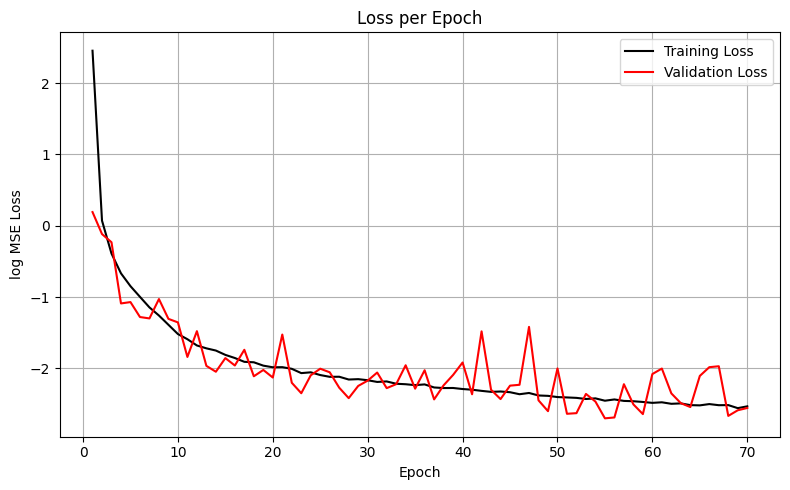

In [ ]:
# ---- Plot all losses on one figure ----
plt.figure(figsize=(8, 5))

# Plot all lines on the same axes
plt.plot(range(1, len(train_losses)+1), np.log(train_losses), label='Training Loss', color='black')
plt.plot(range(1, len(val_losses)+ 1), np.log(val_losses), label='Validation Loss', color='red')

# Labels and title
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("log MSE Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


##### Quick Model Performance Checks

In [ ]:
model.eval()
with torch.no_grad():
    val_output = model(X_val_tensor)

# Convert to numpy
y_pred = val_output.numpy()
y_true = y_val

# --- Metrics ---
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
max_err = max_error(y_true, y_pred)
min_err = np.min(y_true - y_pred)  # smallest (most negative) residual

#print(f"Test Loss (MSE): {avg_train_loss.item():.6f}")
print(f"Validation Set")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")
print(f"Maximum Error: {max_err:.6f}")
print(f"Minimum Error: {min_err:.6f}")

Validation Set
RMSE: 0.259202
MAE: 0.198650
R²: 0.999802
Maximum Error: 1.463520
Minimum Error: -1.268957


In [ ]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    val_pred = model(X_val_tensor)
    test_pred = model(X_test_tensor)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred.numpy()))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred.numpy()))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred.numpy()))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Val RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 0.2620
Val RMSE: 0.2592
Test RMSE: 0.3647


In [ ]:
# Save best model
save_path = "C:/Users/nerc-user/OneDrive - Nexus365/UTCI_NN/ERA5_exploration/results/utci_nn_weights.pth"
torch.save(model.state_dict(), save_path)
print(f"Weights saved to {save_path}")

Weights saved to C:/Users/nerc-user/OneDrive - Nexus365/UTCI_NN/ERA5_exploration/results/utci_nn_weights.pth


### reopen saved model

In [16]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 79),
            nn.ReLU(),
            nn.Linear(79, 75),
            nn.ReLU(),
            nn.Linear(75, 39),
            nn.ReLU(),
            nn.Linear(39, 1)  
        )
        
    def forward(self, x):
        return self.model(x)

model = NeuralNet()

save_path = "C:/Users/nerc-user/OneDrive - Nexus365/UTCI_NN/ERA5_exploration/results/utci_nn_weights.pth"

state_dict = torch.load(save_path, map_location="cpu")
model.load_state_dict(state_dict)


<All keys matched successfully>

## Model evalutian

In [12]:
def evaluate_with_tolerance_bands(y_true, y_pred, dataset_name="Test"):
    """
    Comprehensive evaluation including tolerance bands for UTCI predictions.
    
    Parameters:
    -----------
    y_true : array-like
        True UTCI offset values
    y_pred : array-like
        Predicted UTCI offset values
    dataset_name : str
        Name of the dataset being evaluated
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    
    # Convert to numpy arrays if needed
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Calculate absolute errors
    abs_errors = np.abs(y_pred - y_true)
    
    # Standard metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mbe = np.mean(y_pred - y_true)  # Mean Bias Error
    r2 = r2_score(y_true, y_pred)
    
    # Tolerance bands
    within_0_5 = np.mean(abs_errors <= 0.5) * 100
    within_1_0 = np.mean(abs_errors <= 1.0) * 100
    within_2_0 = np.mean(abs_errors <= 2.0) * 100
    
    # Additional useful metrics
    max_error = np.max(abs_errors)
    percentile_90 = np.percentile(abs_errors, 90)
    percentile_95 = np.percentile(abs_errors, 95)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} SET EVALUATION")
    print(f"{'='*60}")
    print(f"\nStandard Metrics:")
    print(f"  MAE (Mean Absolute Error):     {mae:.4f}°C")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.4f}°C")
    print(f"  MBE (Mean Bias Error):         {mbe:+.4f}°C")
    print(f"  R² (Coefficient of Determination): {r2:.4f}")
    
    print(f"\nTolerance Bands (% of predictions within):")
    print(f"  ±0.5°C: {within_0_5:5.1f}%  {'✓ Excellent' if within_0_5 >= 80 else ''}")
    print(f"  ±1.0°C: {within_1_0:5.1f}%  {'✓ Good' if within_1_0 >= 90 else ''}")
    print(f"  ±2.0°C: {within_2_0:5.1f}%  {'✓ Acceptable' if within_2_0 >= 95 else ''}")
    
    print(f"\nError Distribution:")
    print(f"  Maximum absolute error: {max_error:.4f}°C")
    print(f"  90th percentile error:  {percentile_90:.4f}°C")
    print(f"  95th percentile error:  {percentile_95:.4f}°C")
    print(f"  Number of samples:      {len(y_true)}")
    print(f"{'='*60}\n")
    
    # Return dictionary for further analysis
    return {
        'mae': mae,
        'rmse': rmse,
        'mbe': mbe,
        'r2': r2,
        'within_0_5': within_0_5,
        'within_1_0': within_1_0,
        'within_2_0': within_2_0,
        'max_error': max_error,
        'p90_error': percentile_90,
        'p95_error': percentile_95,
        'n_samples': len(y_true)
    }


def plot_tolerance_analysis(y_true, y_pred, dataset_name="Test"):
    """
    Create visualization of tolerance band performance.
    
    Parameters:
    -----------
    y_true : array-like
        True UTCI offset values
    y_pred : array-like
        Predicted UTCI offset values
    dataset_name : str
        Name of the dataset being evaluated
    """
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    abs_errors = np.abs(y_pred - y_true)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'UTCI Emulator Performance Analysis - {dataset_name} Set', 
                 fontsize=14, fontweight='bold')
    
    # 1. Prediction vs True scatter plot with tolerance bands
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
    
    # Perfect prediction line
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    # Tolerance bands
    ax1.fill_between([min_val, max_val], 
                     [min_val - 0.5, max_val - 0.5], 
                     [min_val + 0.5, max_val + 0.5], 
                     alpha=0.2, color='green', label='±0.5°C band')
    ax1.fill_between([min_val, max_val], 
                     [min_val - 1.0, max_val - 1.0], 
                     [min_val + 1.0, max_val + 1.0], 
                     alpha=0.1, color='yellow', label='±1.0°C band')
    
    ax1.set_xlabel('True UTCI Offset (°C)', fontsize=11)
    ax1.set_ylabel('Predicted UTCI Offset (°C)', fontsize=11)
    ax1.set_title('Predictions vs True Values')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')
    
    # 2. Error distribution histogram
    ax2 = axes[0, 1]
    ax2.hist(abs_errors, bins=50, edgecolor='black', alpha=0.7)
    ax2.axvline(0.5, color='green', linestyle='--', linewidth=2, label='±0.5°C')
    ax2.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='±1.0°C')
    ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='±2.0°C')
    ax2.set_xlabel('Absolute Error (°C)', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Error Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Cumulative error distribution
    ax3 = axes[1, 0]
    sorted_errors = np.sort(abs_errors)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
    ax3.plot(sorted_errors, cumulative, linewidth=2)
    ax3.axvline(0.5, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvline(1.0, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvline(2.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axhline(95, color='gray', linestyle=':', linewidth=1)
    ax3.set_xlabel('Absolute Error (°C)', fontsize=11)
    ax3.set_ylabel('Cumulative Percentage (%)', fontsize=11)
    ax3.set_title('Cumulative Error Distribution')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(left=0)
    
    # Add annotations
    within_0_5 = np.mean(abs_errors <= 0.5) * 100
    within_1_0 = np.mean(abs_errors <= 1.0) * 100
    within_2_0 = np.mean(abs_errors <= 2.0) * 100
    ax3.text(0.5, within_0_5, f'{within_0_5:.1f}%', 
             verticalalignment='bottom', fontsize=9, color='green', fontweight='bold')
    ax3.text(1.0, within_1_0, f'{within_1_0:.1f}%', 
             verticalalignment='bottom', fontsize=9, color='orange', fontweight='bold')
    ax3.text(2.0, within_2_0, f'{within_2_0:.1f}%', 
             verticalalignment='bottom', fontsize=9, color='red', fontweight='bold')
    
    # 4. Residuals vs Predicted (check for bias)
    ax4 = axes[1, 1]
    residuals = y_pred - y_true
    ax4.scatter(y_true, residuals, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
    ax4.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
    ax4.axhline(0.5, color='green', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(-0.5, color='green', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(1.0, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(-1.0, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.set_xlabel('True UTCI Offset (°C)', fontsize=11)
    ax4.set_ylabel('Residual (°C)', fontsize=11)
    ax4.set_title('Residual Plot')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


# Example usage with your model:
"""
# After training your model:
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor).numpy()
    y_pred_val = model(X_val_tensor).numpy()
    y_pred_test = model(X_test_tensor).numpy()

# Evaluate each dataset
train_metrics = evaluate_with_tolerance_bands(y_train.values, y_pred_train, "Training")
val_metrics = evaluate_with_tolerance_bands(y_val.values, y_pred_val, "Validation")
test_metrics = evaluate_with_tolerance_bands(y_test.values, y_pred_test, "Test")

# Create visualizations
plot_tolerance_analysis(y_train.values, y_pred_train, "Training")
plot_tolerance_analysis(y_val.values, y_pred_val, "Validation")
plot_tolerance_analysis(y_test.values, y_pred_test, "Test")
plt.show()
"""

'\n# After training your model:\nmodel.eval()\nwith torch.no_grad():\n    y_pred_train = model(X_train_tensor).numpy()\n    y_pred_val = model(X_val_tensor).numpy()\n    y_pred_test = model(X_test_tensor).numpy()\n\n# Evaluate each dataset\ntrain_metrics = evaluate_with_tolerance_bands(y_train.values, y_pred_train, "Training")\nval_metrics = evaluate_with_tolerance_bands(y_val.values, y_pred_val, "Validation")\ntest_metrics = evaluate_with_tolerance_bands(y_test.values, y_pred_test, "Test")\n\n# Create visualizations\nplot_tolerance_analysis(y_train.values, y_pred_train, "Training")\nplot_tolerance_analysis(y_val.values, y_pred_val, "Validation")\nplot_tolerance_analysis(y_test.values, y_pred_test, "Test")\nplt.show()\n'


TRAINING SET EVALUATION

Standard Metrics:
  MAE (Mean Absolute Error):     0.2009°C
  RMSE (Root Mean Squared Error): 0.2620°C
  MBE (Mean Bias Error):         -0.0539°C
  R² (Coefficient of Determination): 0.9998

Tolerance Bands (% of predictions within):
  ±0.5°C:  94.0%  ✓ Excellent
  ±1.0°C:  99.8%  ✓ Good
  ±2.0°C: 100.0%  ✓ Acceptable

Error Distribution:
  Maximum absolute error: 1.6635°C
  90th percentile error:  0.4241°C
  95th percentile error:  0.5275°C
  Number of samples:      94178


VALIDATION SET EVALUATION

Standard Metrics:
  MAE (Mean Absolute Error):     0.1987°C
  RMSE (Root Mean Squared Error): 0.2592°C
  MBE (Mean Bias Error):         -0.0554°C
  R² (Coefficient of Determination): 0.9998

Tolerance Bands (% of predictions within):
  ±0.5°C:  94.1%  ✓ Excellent
  ±1.0°C:  99.8%  ✓ Good
  ±2.0°C: 100.0%  ✓ Acceptable

Error Distribution:
  Maximum absolute error: 1.4635°C
  90th percentile error:  0.4202°C
  95th percentile error:  0.5245°C
  Number of samples: 

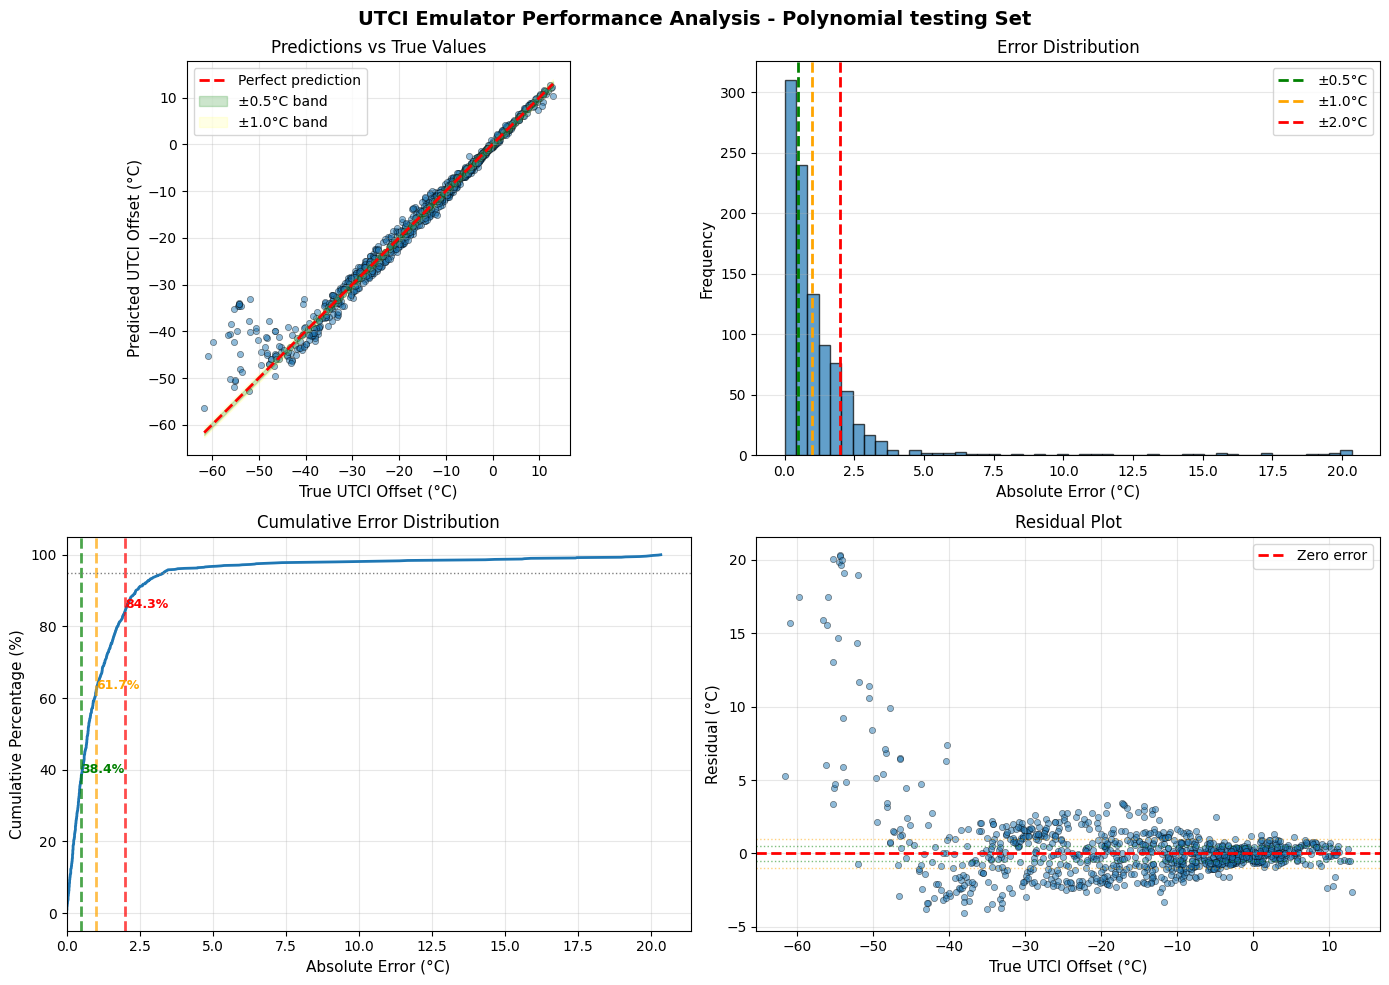

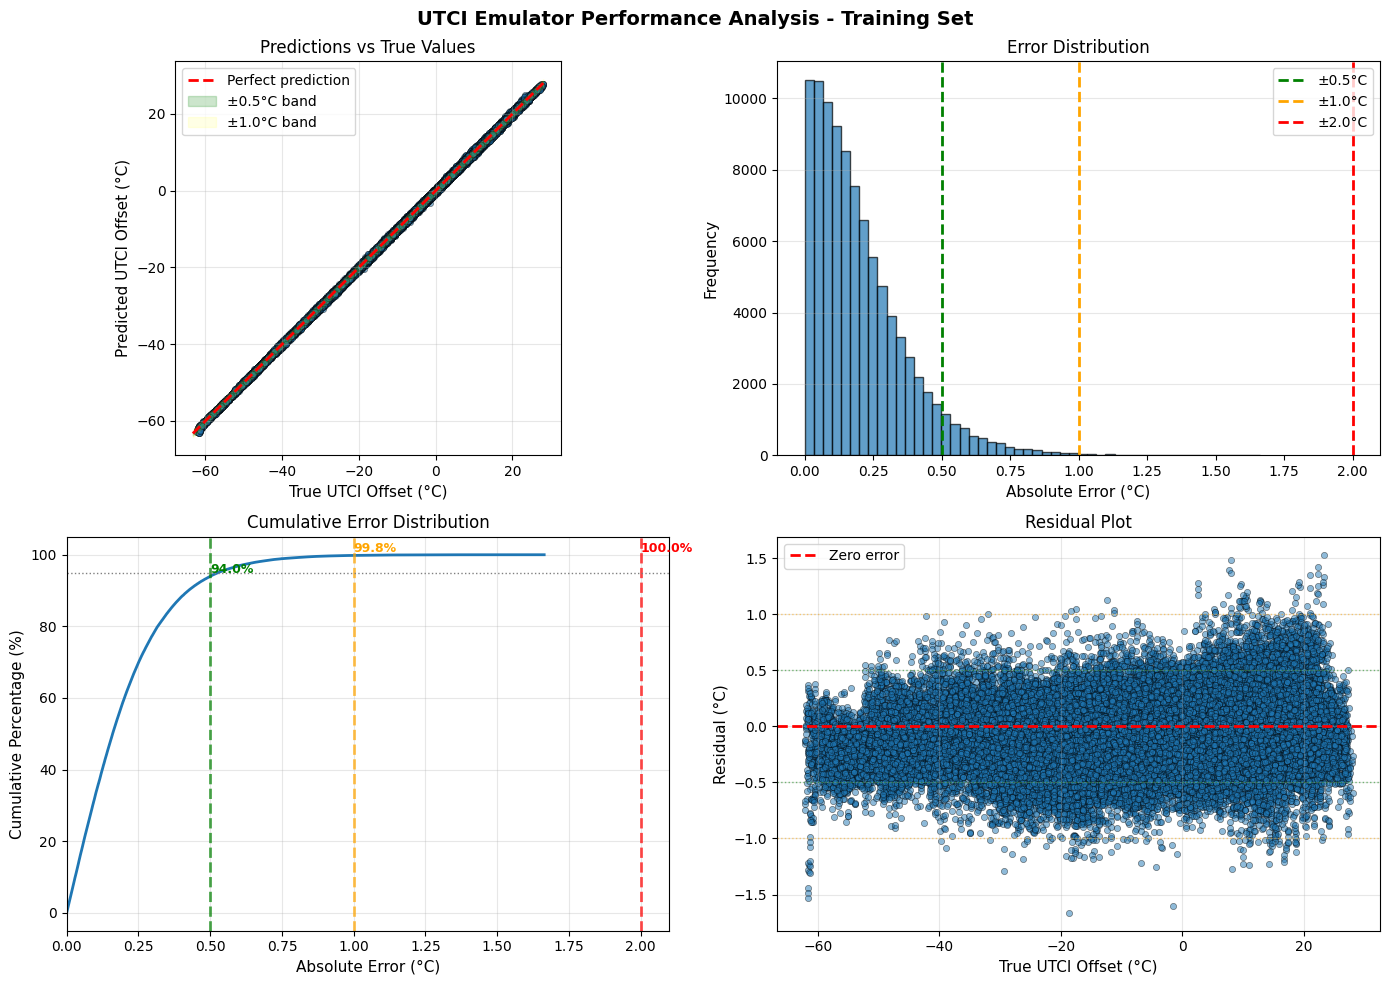

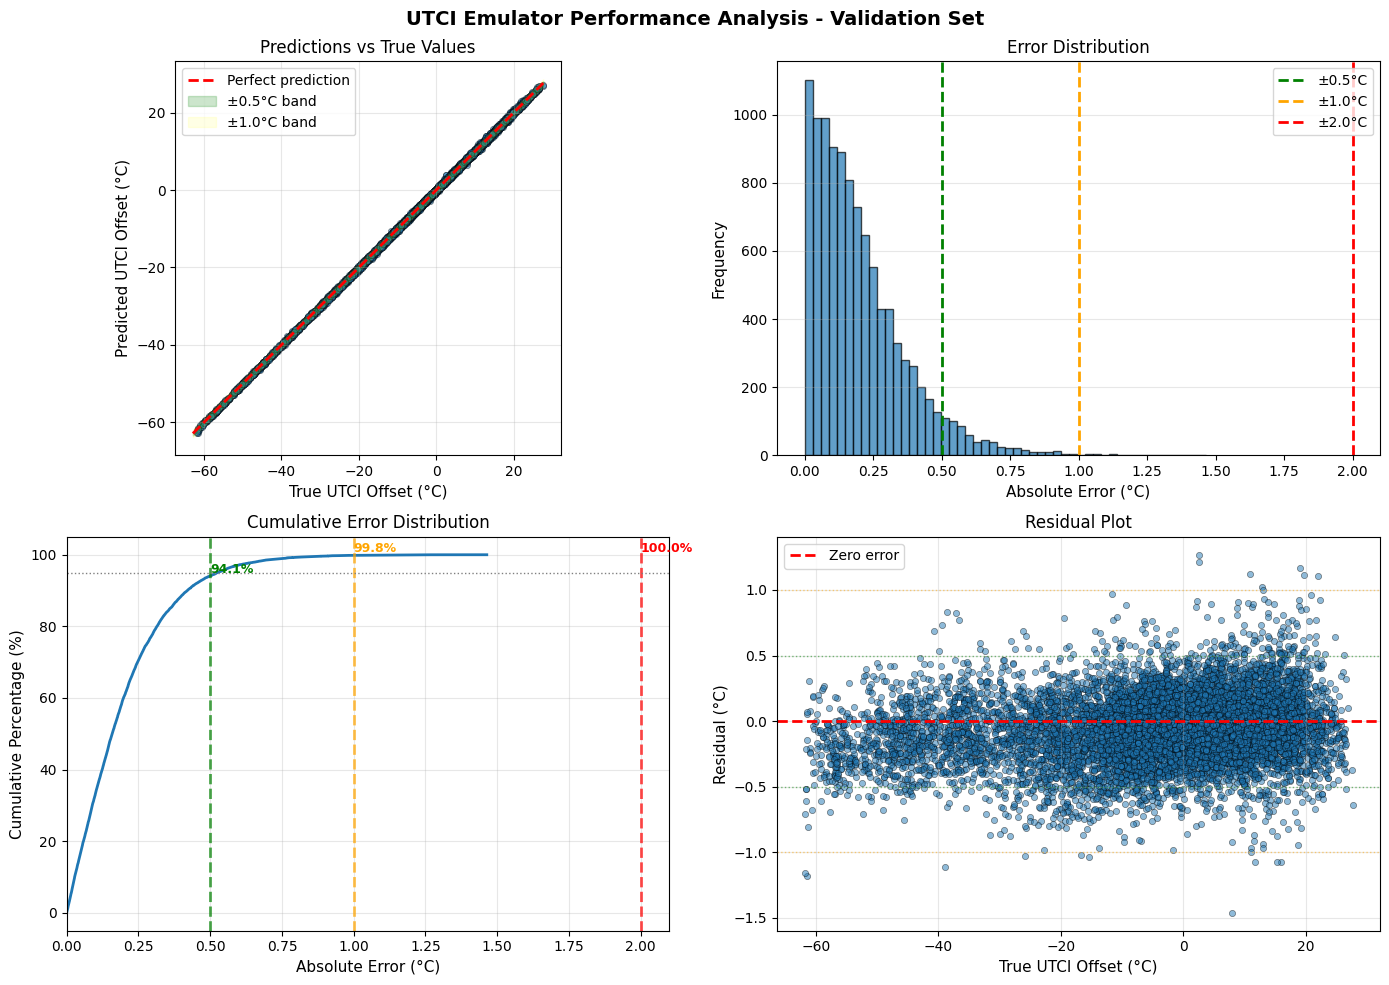

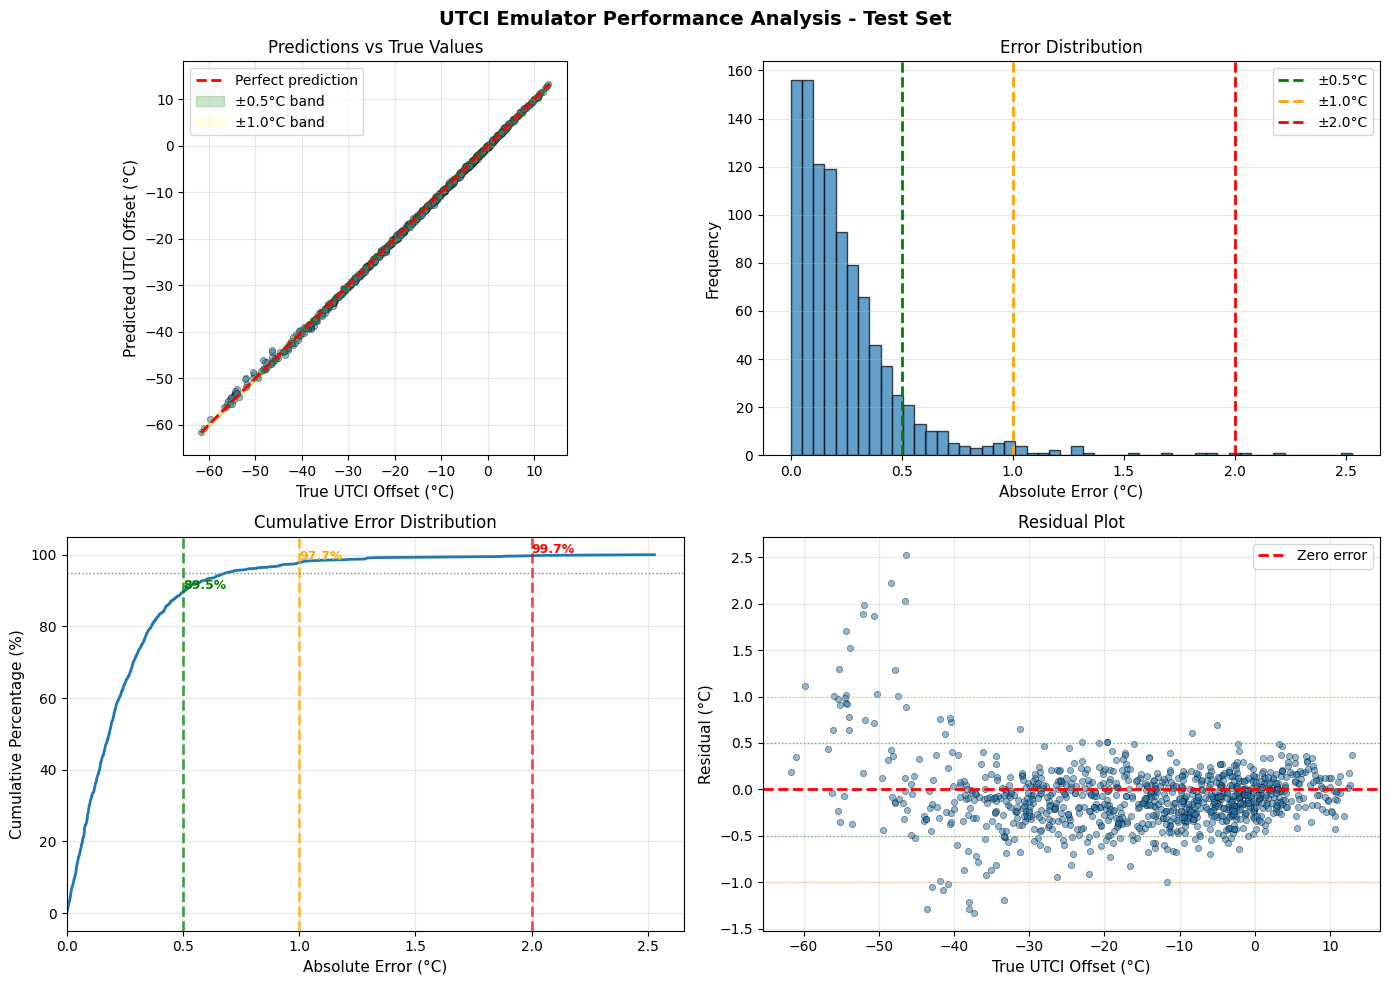

In [13]:
# Comprehensive evaluation with tolerance bands
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor).numpy()
    y_pred_val = model(X_val_tensor).numpy()
    y_pred_test = model(X_test_tensor).numpy()

# Evaluate all datasets
train_metrics = evaluate_with_tolerance_bands(y_train.values, y_pred_train, "Training")
val_metrics = evaluate_with_tolerance_bands(y_val.values, y_pred_val, "Validation")
test_metrics = evaluate_with_tolerance_bands(y_test.values, y_pred_test, "Test")

# Create visualizations
fig_poly = plot_tolerance_analysis(test['Offset'], test['UTCI_polynomial'] - test['Ta'], "Polynomial testing")
fig_train = plot_tolerance_analysis(y_train.values, y_pred_train, "Training")
fig_val = plot_tolerance_analysis(y_val.values, y_pred_val, "Validation")
fig_test = plot_tolerance_analysis(test['Offset'], y_pred_test, "Test")
plt.show()

# Optionally save figures
fig_test.savefig('../results/tolerance_analysis_test.png', dpi=300, bbox_inches='tight')

In [14]:
# Evaluate with wind speed analysis
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).numpy()

# Analyze errors conditioned on wind speed
results = analyze_errors_by_windspeed(
    X_test,              # Original unscaled X_test DataFrame
    y_test.values,       # True offset values
    y_pred_test,         # Predicted offset values
    wind_threshold=17.0,
    dataset_name="Test"
)

# Create visualization
fig = plot_errors_vs_windspeed(X_test, y_test.values, y_pred_test, 
                                wind_threshold=17.0, dataset_name="Test")
plt.show()

# Extract the key metric you asked for
if 'below_threshold' in results:
    max_error_below_17 = results['below_threshold']['max_abs_error']
    print(f"\n Maximum absolute error for va < 17 m/s: {max_error_below_17:.4f}°C")

NameError: name 'analyze_errors_by_windspeed' is not defined

## SHAP ANLAYSIS

In [17]:
import shap
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

### NN Shap

In [18]:
feature_names = X_train.columns.tolist()

In [19]:
def model_predict(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        return model(x_tensor).numpy()

X_train_np = X_train.values
X_test_np = X_test.values

explainer_nn = shap.Explainer(model_predict, X_train_np, feature_names=feature_names)
shap_values_nn = explainer_nn(X_test_np)


ExactExplainer explainer: 1001it [00:17, 58.58it/s]                          


### Polynomial Shap

In [20]:
poly = PolynomialFeatures(degree=6, include_bias=False)
scaler = StandardScaler()
lin_reg = LinearRegression()

# Fit scaler and polynomial features on training data
X_train_scaled = scaler.fit_transform(X_train)
X_train_poly = poly.fit_transform(X_train_scaled)
lin_reg.fit(X_train_poly, y_train)

# Wrap so SHAP sees original features
def poly_predict(X):
    X_scaled = scaler.transform(X)          # scale original features
    X_poly = poly.transform(X_scaled)       # apply polynomial transformation
    return lin_reg.predict(X_poly)


# SHAP explainer on original features
explainer_lr = shap.Explainer(poly_predict, X_train, feature_names=feature_names)
shap_values_lr = explainer_lr(X_test)

## Plot the Shap features

In [21]:
new_feature_names = [
    "Air Temp.",
    "Wind Speed",
    "Relative\nHumidity",
    "Mean Radiant\nTemp.",
]

shap_values_lr.feature_names = new_feature_names
shap_values_nn.feature_names = new_feature_names


### PDP plots

In [23]:
shap_values_nn.feature_names

['Air Temp.', 'Wind Speed', 'Relative\nHumidity', 'Mean Radiant\nTemp.']

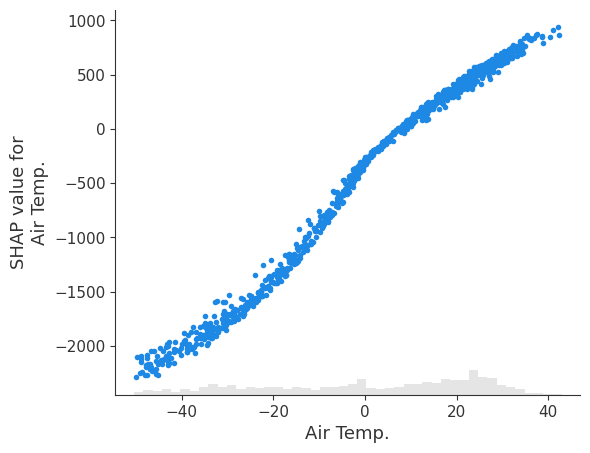

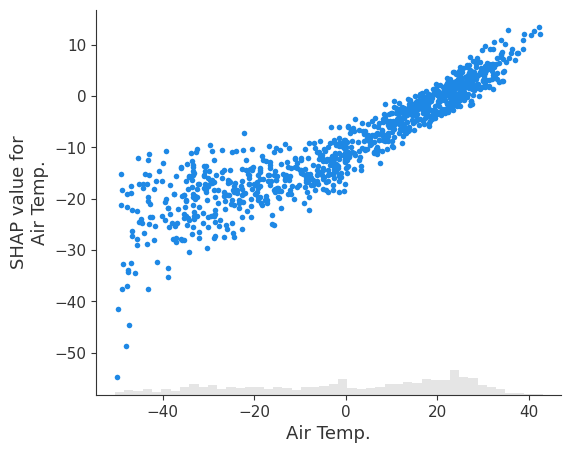

In [27]:
shap.plots.scatter(shap_values_nn[:, 0])
shap.plots.scatter(shap_values_lr[:, 0])

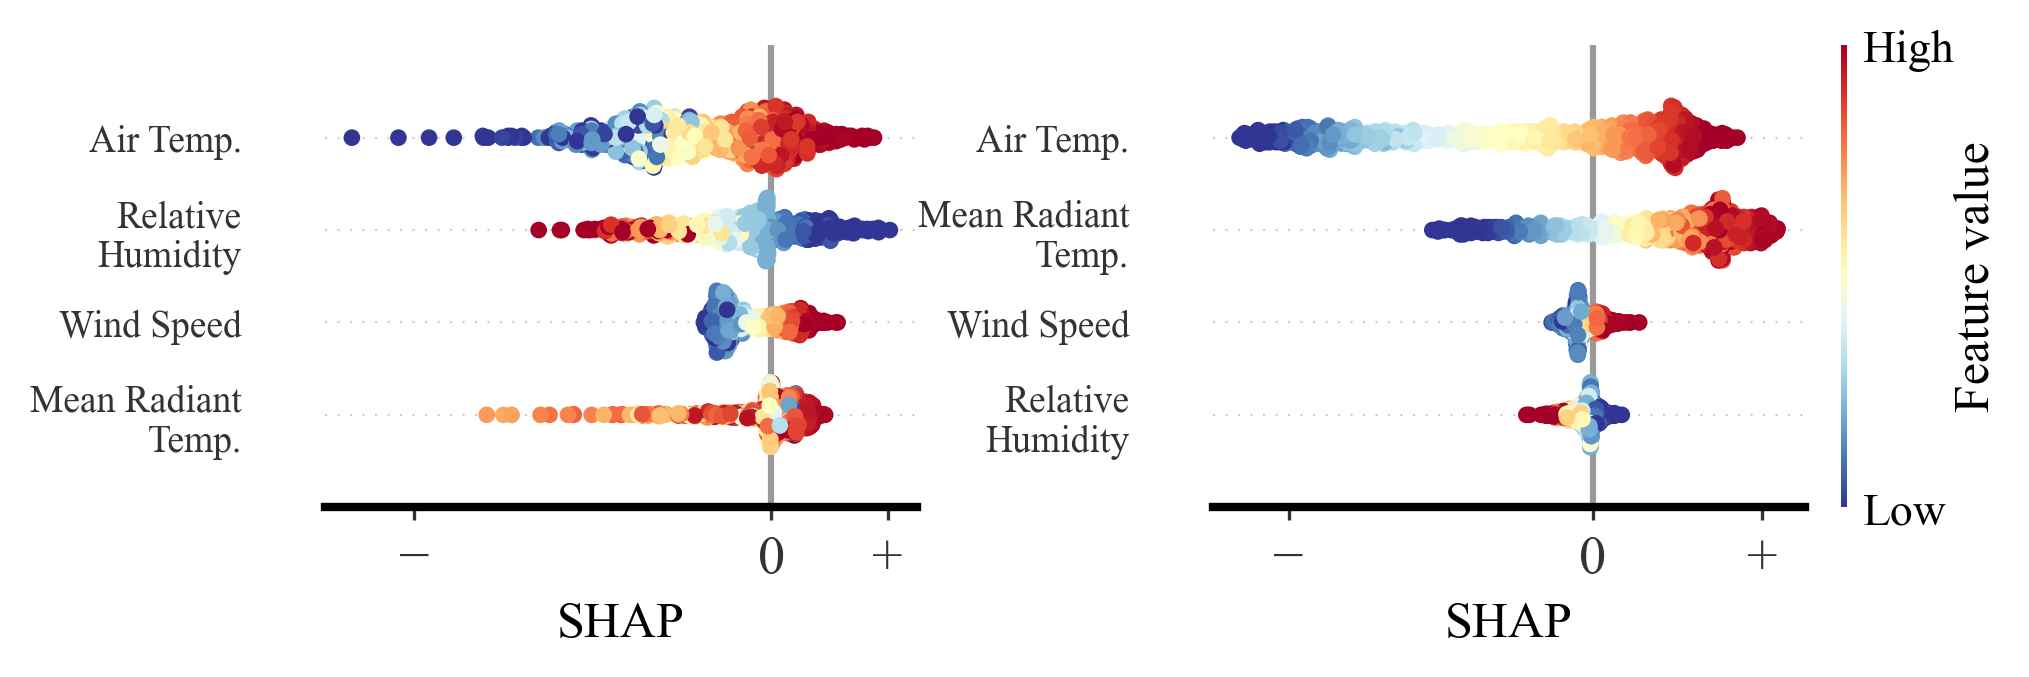

In [42]:
# Publication-quality parameters
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 2.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 6,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Create figure and axes
fig, axs = plt.subplots(1, 2, figsize=(7, 2))

# Column titles
# axs[0].set_title('Polynomial Model', fontsize=13, pad=8, fontweight='bold', loc='center')
# axs[1].set_title('Neural Network Model', fontsize=13, pad=8, fontweight='bold', loc='center')
axs[0].set_xlabel("SHAP", fontsize=12, fontname='Times New Roman')
axs[1].set_xlabel("SHAP", fontsize=12)

# Colormap (passed directly to SHAP)
cmap = plt.get_cmap("RdYlBu_r")

# --- Plot beeswarms ---
shap.plots.beeswarm(
    shap_values_lr,
    ax=axs[0],
    show=False,
    plot_size=None,
    color=cmap
)

shap.plots.beeswarm(
    shap_values_nn,
    ax=axs[1],
    show=False,
    plot_size=None,
    color=cmap
)

# --- Suppress the FIRST colorbar only ---
# SHAP creates colorbars as extra axes at the figure level.
# The first colorbar axis is the first non-data axis added.
fig_axes = fig.get_axes()

# data axes are axs[0] and axs[1]; the remaining ones are colorbars
colorbar_axes = [ax for ax in fig_axes if ax not in axs]

if len(colorbar_axes) > 1:
    colorbar_axes[0].remove()   # remove the left colorbar

# --- Axis formatting ---
for ax in axs:
    ax.set_ylabel("")

    # X-axis ticks: − 0 +
    x_min, x_max = ax.get_xlim()
    pos_tick = x_max * 0.8 if x_max > 0 else 0.1
    neg_tick = x_min * 0.8 if x_min < 0 else -0.1
    ax.set_xticks([neg_tick, 0, pos_tick])
    ax.set_xticklabels(['−', '0', '+'], fontsize=10)
    ax.set_xlabel("SHAP", fontsize=12)
    ax.tick_params(axis='x', labelsize=13, length=3, width=0.8)
    ax.tick_params(axis='y', labelsize=9, pad=0)
    ax.tick_params(axis='y', labelsize=9)

# # Panel labels
# panel_labels = ['a', 'b']
# for idx, ax in enumerate(axs.flat):
#     ax.text(-0.13, 1.05, panel_labels[idx],
#             transform=ax.transAxes,
#             fontsize=14, fontweight='bold',
#             va='top', ha='left')

# Layout and save
#plt.subplots_adjust(left=0.06, right=0.94, top=0.94, bottom=0.12, wspace=0.35)

out_base = "../figures/main_text/shap_beeswarm"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
plt.show()


In [45]:
import matplotlib.pyplot as plt
import shap

# --- Your rcParams (kept as provided) ---
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 2.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 6,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

cmap = plt.get_cmap("RdYlBu_r")

def plot_and_save_single_beeswarm(shap_values, out_path,
                                  figsize=(3.5, 2),
                                  xlabel="SHAP",
                                  ytick_labelsize=8,
                                  ytick_pad=1):
    """
    Plot a single SHAP beeswarm on its own figure and save to out_path.
    - shap_values: shap.Explanation (or equivalent) for this model
    - out_path: file path to save (e.g. "../figures/shap_lr.png")
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # x-label (keeps your Times New Roman if desired)
    ax.set_xlabel(xlabel, fontsize=12, fontname='Times New Roman')

    # Plot the beeswarm on this single axis
    shap.plots.beeswarm(
        shap_values,
        ax=ax,
        show=False,
        plot_size=None,
        color=cmap
    )

    # SHAP sometimes adds colorbar axes at figure level; remove any non-data axes
    fig_axes = fig.get_axes()
    extra_axes = [a for a in fig_axes if a is not ax]
    for extra in extra_axes:
        extra.remove()

    # Axis formatting (match what you used before)
    # Remove y-axis label if any
    ax.set_ylabel("")
    ax.set_xlabel("SHAP", fontsize=12)

    # X-axis ticks: − 0 +
    x_min, x_max = ax.get_xlim()
    pos_tick = x_max * 0.8 if x_max > 0 else 0.1
    neg_tick = x_min * 0.8 if x_min < 0 else -0.1
    ax.set_xticks([neg_tick, 0, pos_tick])
    ax.set_xticklabels(['−', '0', '+'], fontsize=10)
    ax.tick_params(axis='x', labelsize=13, length=3, width=0.8)

    # Y-tick size + distance to axis (pad)
    ax.tick_params(axis='y', labelsize=ytick_labelsize, pad=ytick_pad)

    # Force draw to compute tight bounding boxes correctly
    fig.canvas.draw()

    # Save tight (includes tick labels)
    fig.savefig(out_path, dpi=600, bbox_inches='tight', pad_inches=0.01)

    plt.close(fig)  # close to free memory

# ---- Calls for your two models ----
plot_and_save_single_beeswarm(shap_values_lr,
                              "../figures/main_text/shap_beeswarm_lr.png",
                              figsize=(3.5, 2),
                              ytick_labelsize=8,
                              ytick_pad=1)

plot_and_save_single_beeswarm(shap_values_nn,
                              "../figures/main_text/shap_beeswarm_nn.png",
                              figsize=(3.5, 2),
                              ytick_labelsize=8,
                              ytick_pad=1)


## SHAP PDPS to test:

**1. Humidity Effects:**

- At low air temperatures, humidity has a small effect on UTCI.

- At moderate temperatures:

    - Relative humidity above 50% slightly increases UTCI.

    - Relative humidity below 50% slightly decreases UTCI.


**2. Wind Speed Effects:**

- The effect of wind on UTCI depends on air temperature.

- Wind increases heat stress at temperatures above ~35 °C.

- Wind increases cold stress at low air temperatures.


**3. Thermal Radiation Effects:**

- UTCI increases linearly with thermal radiation intensity, about 3 K per 10 K increase in mean radiant temperature.

- At very low temperatures and high wind speeds, the effect of radiation on UTCI is reduced.

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_12708\1837599957.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 0.95, 0.98])


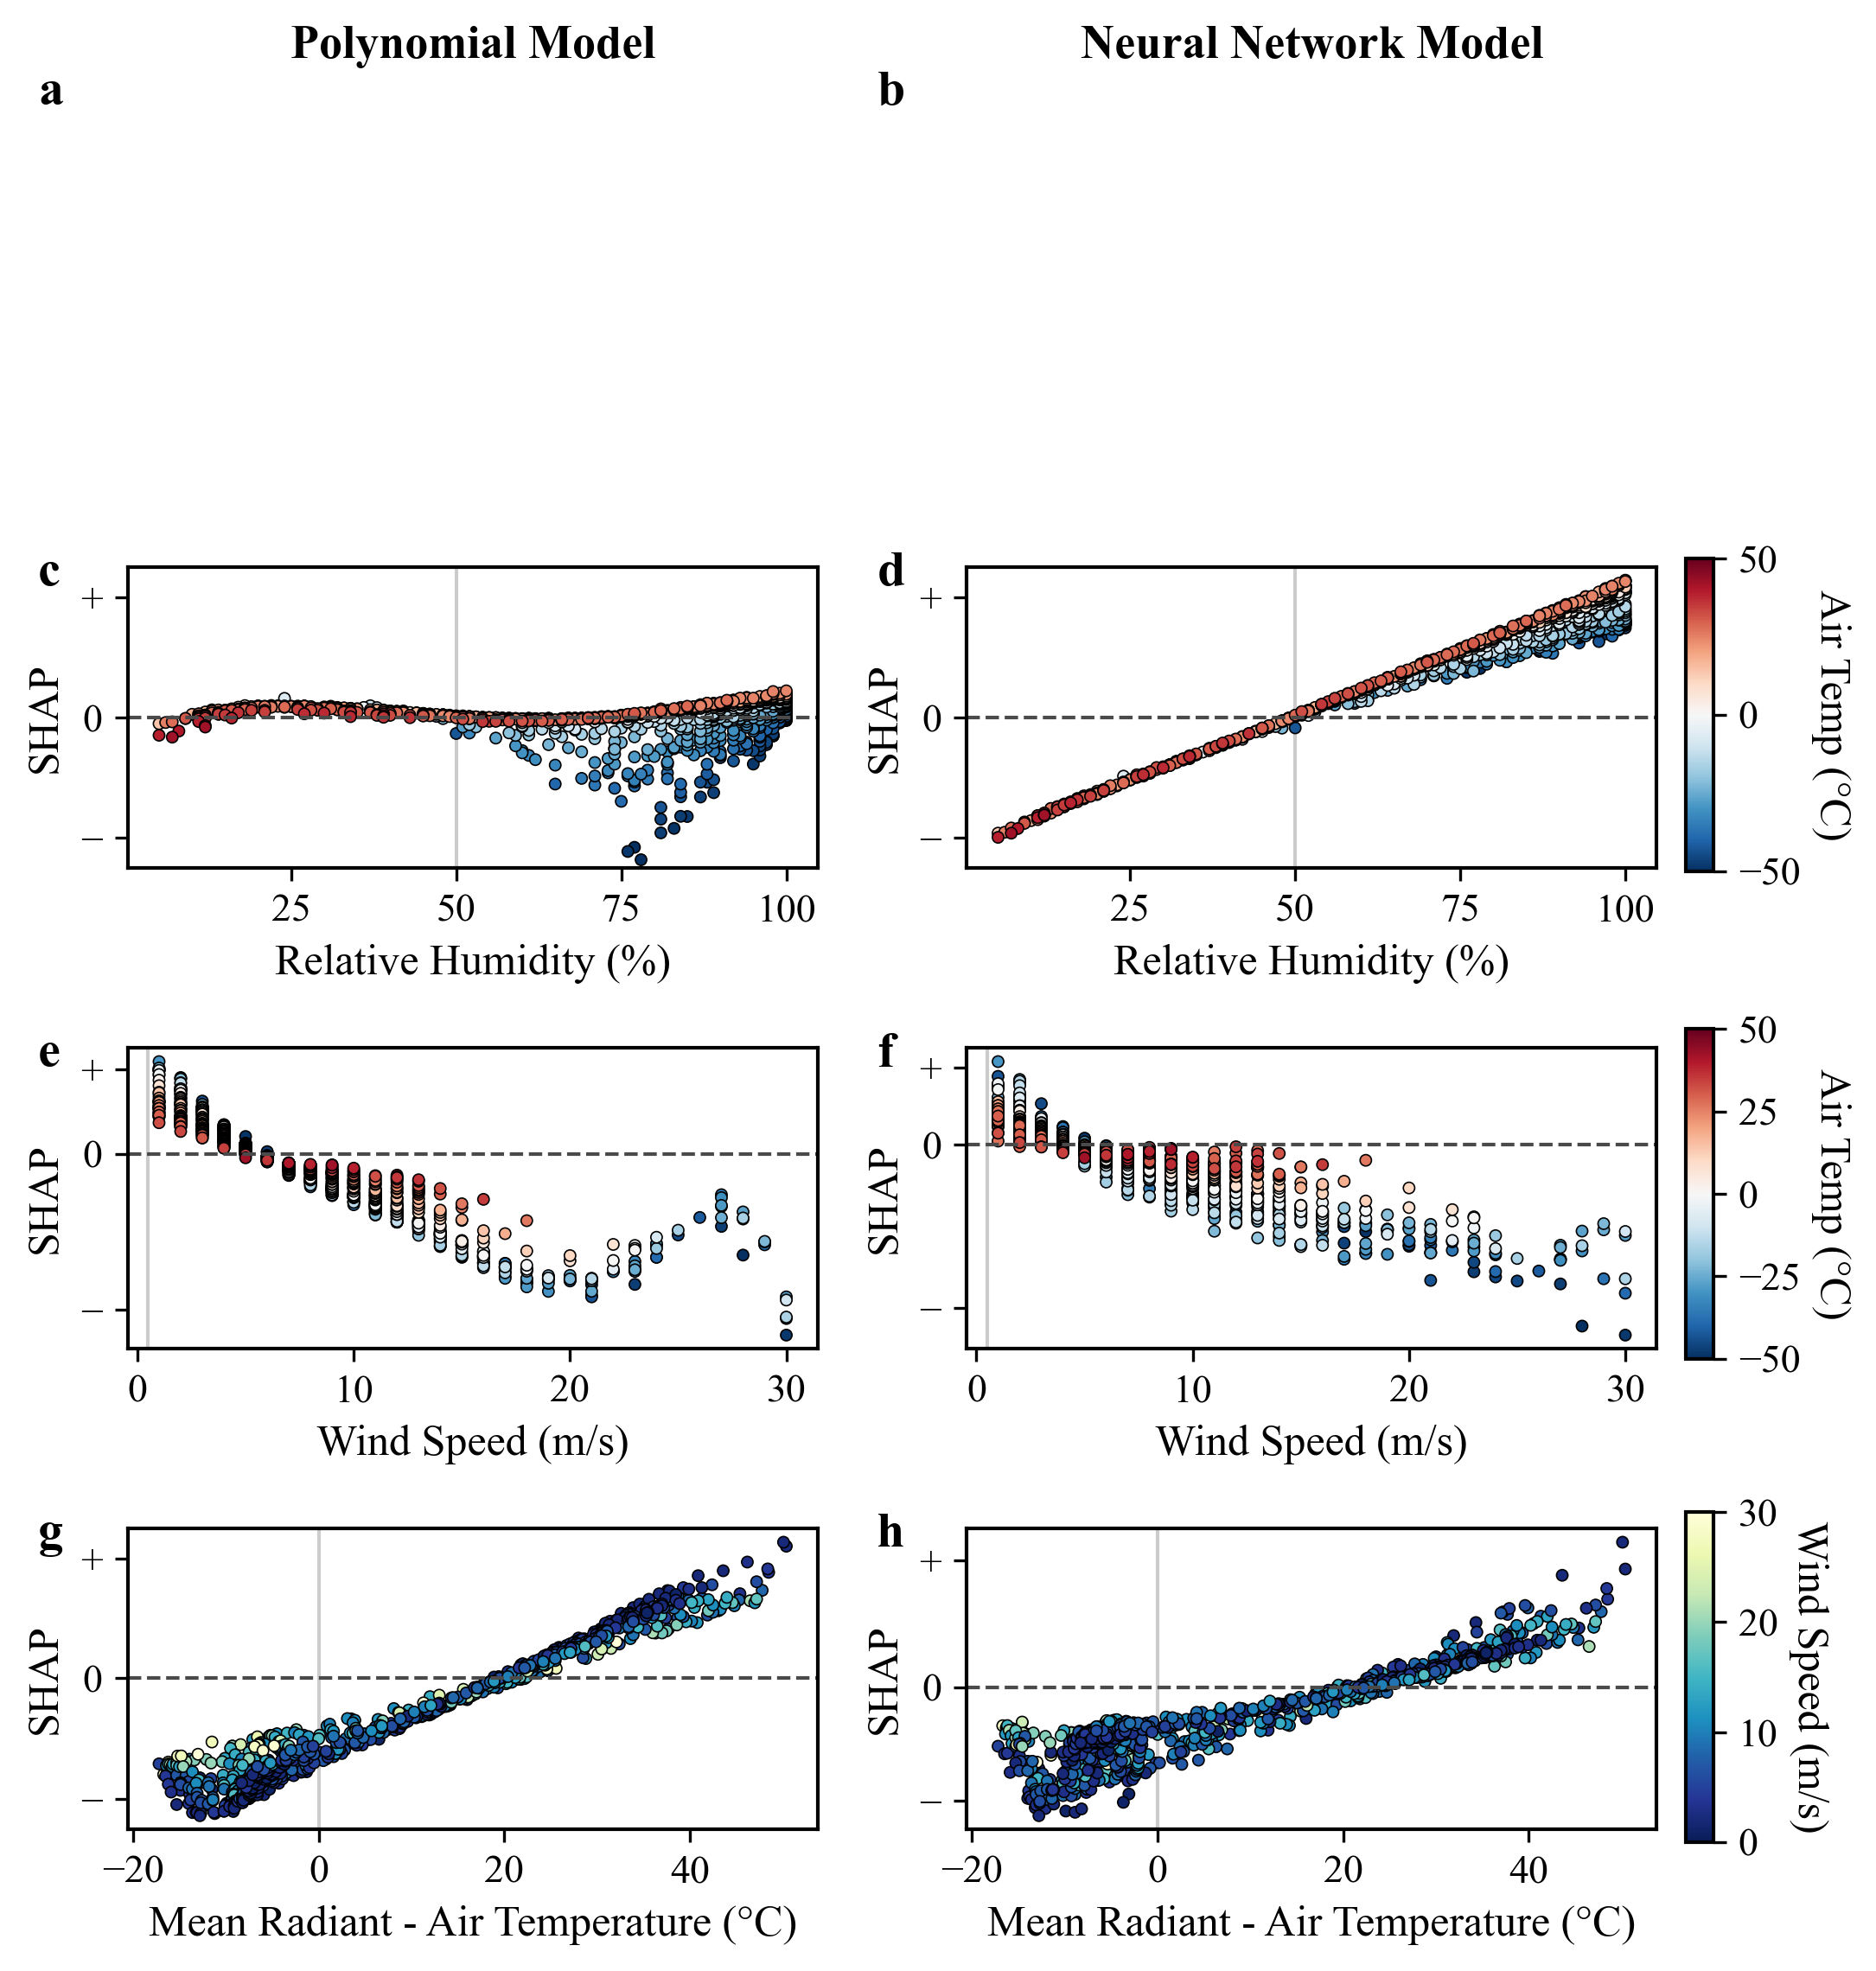

Saved: ../figures/main_text/shap_dependence_analysis_with_blank_top.png and ../figures/main_text/shap_dependence_analysis_with_blank_top.pdf


In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Keep a copy of original rcParams so we can restore later
_original_rc = plt.rcParams.copy()

# ---------- Publication-quality rc settings ----------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------- Simple helper to add a colorbar for a single axis ----------
def simple_add_cbar(fig, ax, mappable, side='right', size=0.02, pad=0.04, shrink=1.0, y_offset=0.0, **cbar_kwargs):
    pos = ax.get_position()
    if side == 'right':
        x = pos.x1 + pad
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'left':
        x = pos.x0 - pad - size
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'top':
        y = pos.y1 + pad
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    elif side == 'bottom':
        y = pos.y0 - pad - size
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    else:
        raise ValueError("side must be 'right','left','top' or 'bottom'")

    cbar = fig.colorbar(mappable, cax=cax, orientation=orientation, **cbar_kwargs)
    return cbar, cax


# ---------- Figure setup ----------
# Now 4 rows × 2 columns: top row reserved for empty panels (a,b), others hold the original plots
fig_w, fig_h = 7.0, 8.0
fig, axs = plt.subplots(4, 2, figsize=(fig_w, fig_h), squeeze=True)

# ---------- Feature names and settings ----------
feature_names = ['Ta', 'Tr-Ta', 'va', 'rH']

# Plot settings for 3 plotted rows (they will be placed on rows 1,2,3 of the grid)
plot_configs = [
    (3, 0, "Air Temp (°C)", "Relative Humidity (%)", 50),      # plotted row -> label 'c' (original row 0)
    (2, 0, "Air Temp (°C)", "Wind Speed (m/s)", 0.5),          # plotted row -> label 'e' (original row 1)
    (1, 2, "Wind Speed (m/s)", "Mean Radiant - Air Temperature (°C)", 0) # plotted row -> label 'g' (original row 2)
]

# ---------- Plotting parameters ----------
point_size = 10
alpha_val = 1.0

# Define colormaps and normalizations for each plotted row (order corresponds to plot_configs)
row_cmap_settings = [
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),  # plotted row 0
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),  # plotted row 1
    (plt.get_cmap('YlGnBu_r'), mcolors.Normalize(vmin=0, vmax=30))                 # plotted row 2
]

# Colorbar specs for each plotted row (corresponds to plot_configs)
colorbar_specs = [
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.90, 'y_offset':  0.03},  # for row 0
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset':  0}, # for row 1
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset': -0.032}  # for row 2
]

# ---------- Make top row (0) empty but with no ticks and no spines ----------
for col in range(2):
    ax_top = axs[0, col]
    # remove ticks and spines to make it appear empty but keep the axes (so panel labels go there)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    for spine in ax_top.spines.values():
        spine.set_visible(False)

# ---------- All plotted rows: Dependence plots ----------
# base_row is where plotting begins (1 because row 0 is reserved)
base_row = 1
for row_idx, (feature_idx, color_idx, color_label, feature_label, ref_value) in enumerate(plot_configs):
    # actual row in the grid
    actual_row = base_row + row_idx

    # Get colormap and normalization for this plotted row
    cmap, norm = row_cmap_settings[row_idx]

    row_scatter = None
    row_color_label = color_label

    for col in range(2):
        ax = axs[actual_row, col]

        # Select appropriate SHAP values
        shap_vals = shap_values_lr if col == 0 else shap_values_nn

        # Resolve SHAP array-like to numpy array (works with DataFrame-like or numpy)
        if hasattr(shap_vals, 'values'):
            shap_array = np.asarray(shap_vals.values)
        else:
            shap_array = np.asarray(shap_vals)

        # Get the data for coloring (ensure numpy array)
        color_data = np.asarray(X_test.iloc[:, color_idx].values)

        # Ensure X data is numpy array
        x_data = np.asarray(X_test.iloc[:, feature_idx].values)

        # Create scatter plot manually for better control
        scatter = ax.scatter(
            x_data,
            shap_array[:, feature_idx],
            c=color_data,
            s=point_size,
            alpha=alpha_val,
            cmap=cmap,
            norm=norm,
            linewidths=0.4,
            edgecolors='black',
            rasterized=True
        )

        # Styling
        ax.set_xlabel(feature_label, fontsize=12)
        ax.set_ylabel('SHAP', fontsize=12)
        ax.tick_params(labelsize=11)
        ax.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1.0)

        # Add vertical reference line at reference value
        ax.axvline(ref_value, color='gray', linestyle='-', linewidth=1, alpha=0.4, zorder=-1)

        # For first plotted row, make y-axis symmetrical
        if row_idx == 0:
            ylim = ax.get_ylim()
            max_abs = max(abs(ylim[0]), abs(ylim[1]))
            ax.set_ylim(-max_abs, max_abs)

        # Set y-axis ticks: one positive, zero, one negative with only signs
        ylim = ax.get_ylim()
        y_max = ylim[1]
        y_min = ylim[0]
        pos_tick = y_max * 0.8 if y_max > 0 else 0.1
        neg_tick = y_min * 0.8 if y_min < 0 else -0.1
        ax.set_yticks([neg_tick, 0, pos_tick])
        ax.set_yticklabels(['−', '0', '+'])

        # Store scatter object for colorbar (use right column scatter so we don't duplicate)
        if col == 1:
            row_scatter = scatter
            row_color_label = color_label

    # add colorbar for this plotted row (positioned next to the right column of the actual_row)
    spec = colorbar_specs[row_idx]
    if row_scatter is None:
        row_scatter = scatter  # fallback

    cbar, cax = simple_add_cbar(
        fig,
        axs[actual_row, 1],    # reference axis to position colorbar beside the right column
        row_scatter,
        side=spec.get('side', 'right'),
        size=spec.get('size', 0.02),
        pad=spec.get('pad', 0.04),
        shrink=spec.get('shrink', 1.0),
        y_offset=spec.get('y_offset', 0.0)
    )
    if spec.get('side', 'right') in ('right', 'left'):
        cbar.set_label(row_color_label, fontsize=12, rotation=270, labelpad=14)
    else:
        cbar.set_label(row_color_label, fontsize=12, rotation=0, labelpad=6)
    cbar.ax.tick_params(labelsize=11)

# ---------- Panel labels ----------
# Now 8 panels (a..h). Top row reserved for 'a' and 'b', rest become c..h.
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# ---------- Column titles ----------
# Titles should go above the first plotted row (which is grid row 1)
axs[0, 0].set_title('Polynomial Model', fontsize=13, pad=8, fontweight='bold')
axs[0, 1].set_title('Neural Network Model', fontsize=13, pad=8, fontweight='bold')

# ---------- Final layout & save ----------
plt.tight_layout(rect=[0, 0.01, 0.95, 0.98])
out_base = "../figures/main_text/shap_dependence_analysis_with_blank_top"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)
plt.show()
print(f"Saved: {out_base}.png and {out_base}.pdf")

# Reset to original rcParams
plt.rcParams.update(_original_rc)


## Save both together

In [115]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# ---------- Publication-quality parameters ----------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 16,
    'axes.titlesize': 13,
    'axes.labelsize': 16,
    'axes.linewidth': 3,
    'xtick.labelsize': 40,
    'ytick.labelsize': 40,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------- Match size of ONE subplot in your 7×6 figure ----------
# 7 inches wide / 2 columns ≈ 3.5 inches
# 6 inches tall / 3 rows ≈ 2.0 inches
subplot_size = (25, 15)

# ---------- Colormap ----------
cmap = plt.get_cmap("RdYlBu_r")

def save_single_beeswarm(shap_values, out_path):
    fig, ax = plt.subplots(1, 1, figsize=subplot_size)

    shap.plots.beeswarm(
        shap_values,
        ax=ax,
        show=False,
        plot_size=None,
        color=cmap
    )

    # Remove y-label (feature names stay, SHAP default)
    ax.set_ylabel("")

    # X-axis ticks: − 0 +
    x_min, x_max = ax.get_xlim()
    pos_tick = x_max * 0.8 if x_max > 0 else 0.1
    neg_tick = x_min * 0.8 if x_min < 0 else -0.1
    ax.set_xticks([neg_tick, 0, pos_tick])
    ax.set_xticklabels(['−', '0', '+'], fontsize=40)
    ax.set_xlabel("SHAP", fontsize=60)

    # Remove any colorbar SHAP may have added
    fig_axes = fig.get_axes()
    extra_axes = [a for a in fig_axes if a is not ax]
    for extra_ax in extra_axes:
        extra_ax.remove()

    fig.savefig(out_path, dpi=600, bbox_inches="tight", pad_inches=0.01)
    plt.close(fig)

# ---------- Save each beeswarm separately ----------
save_single_beeswarm(shap_values_lr, "../figures/shap_beeswarm_lr.png")
save_single_beeswarm(shap_values_nn, "../figures/shap_beeswarm_nn.png")

print("Saved:")
print(" - ../figures/shap_beeswarm_lr.png")
print(" - ../figures/shap_beeswarm_nn.png")


Saved:
 - ../figures/shap_beeswarm_lr.png
 - ../figures/shap_beeswarm_nn.png


C:\Users\nerc-user\AppData\Local\Temp\ipykernel_24252\4111005132.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 0.95, 0.96])  # leave top margin for titles


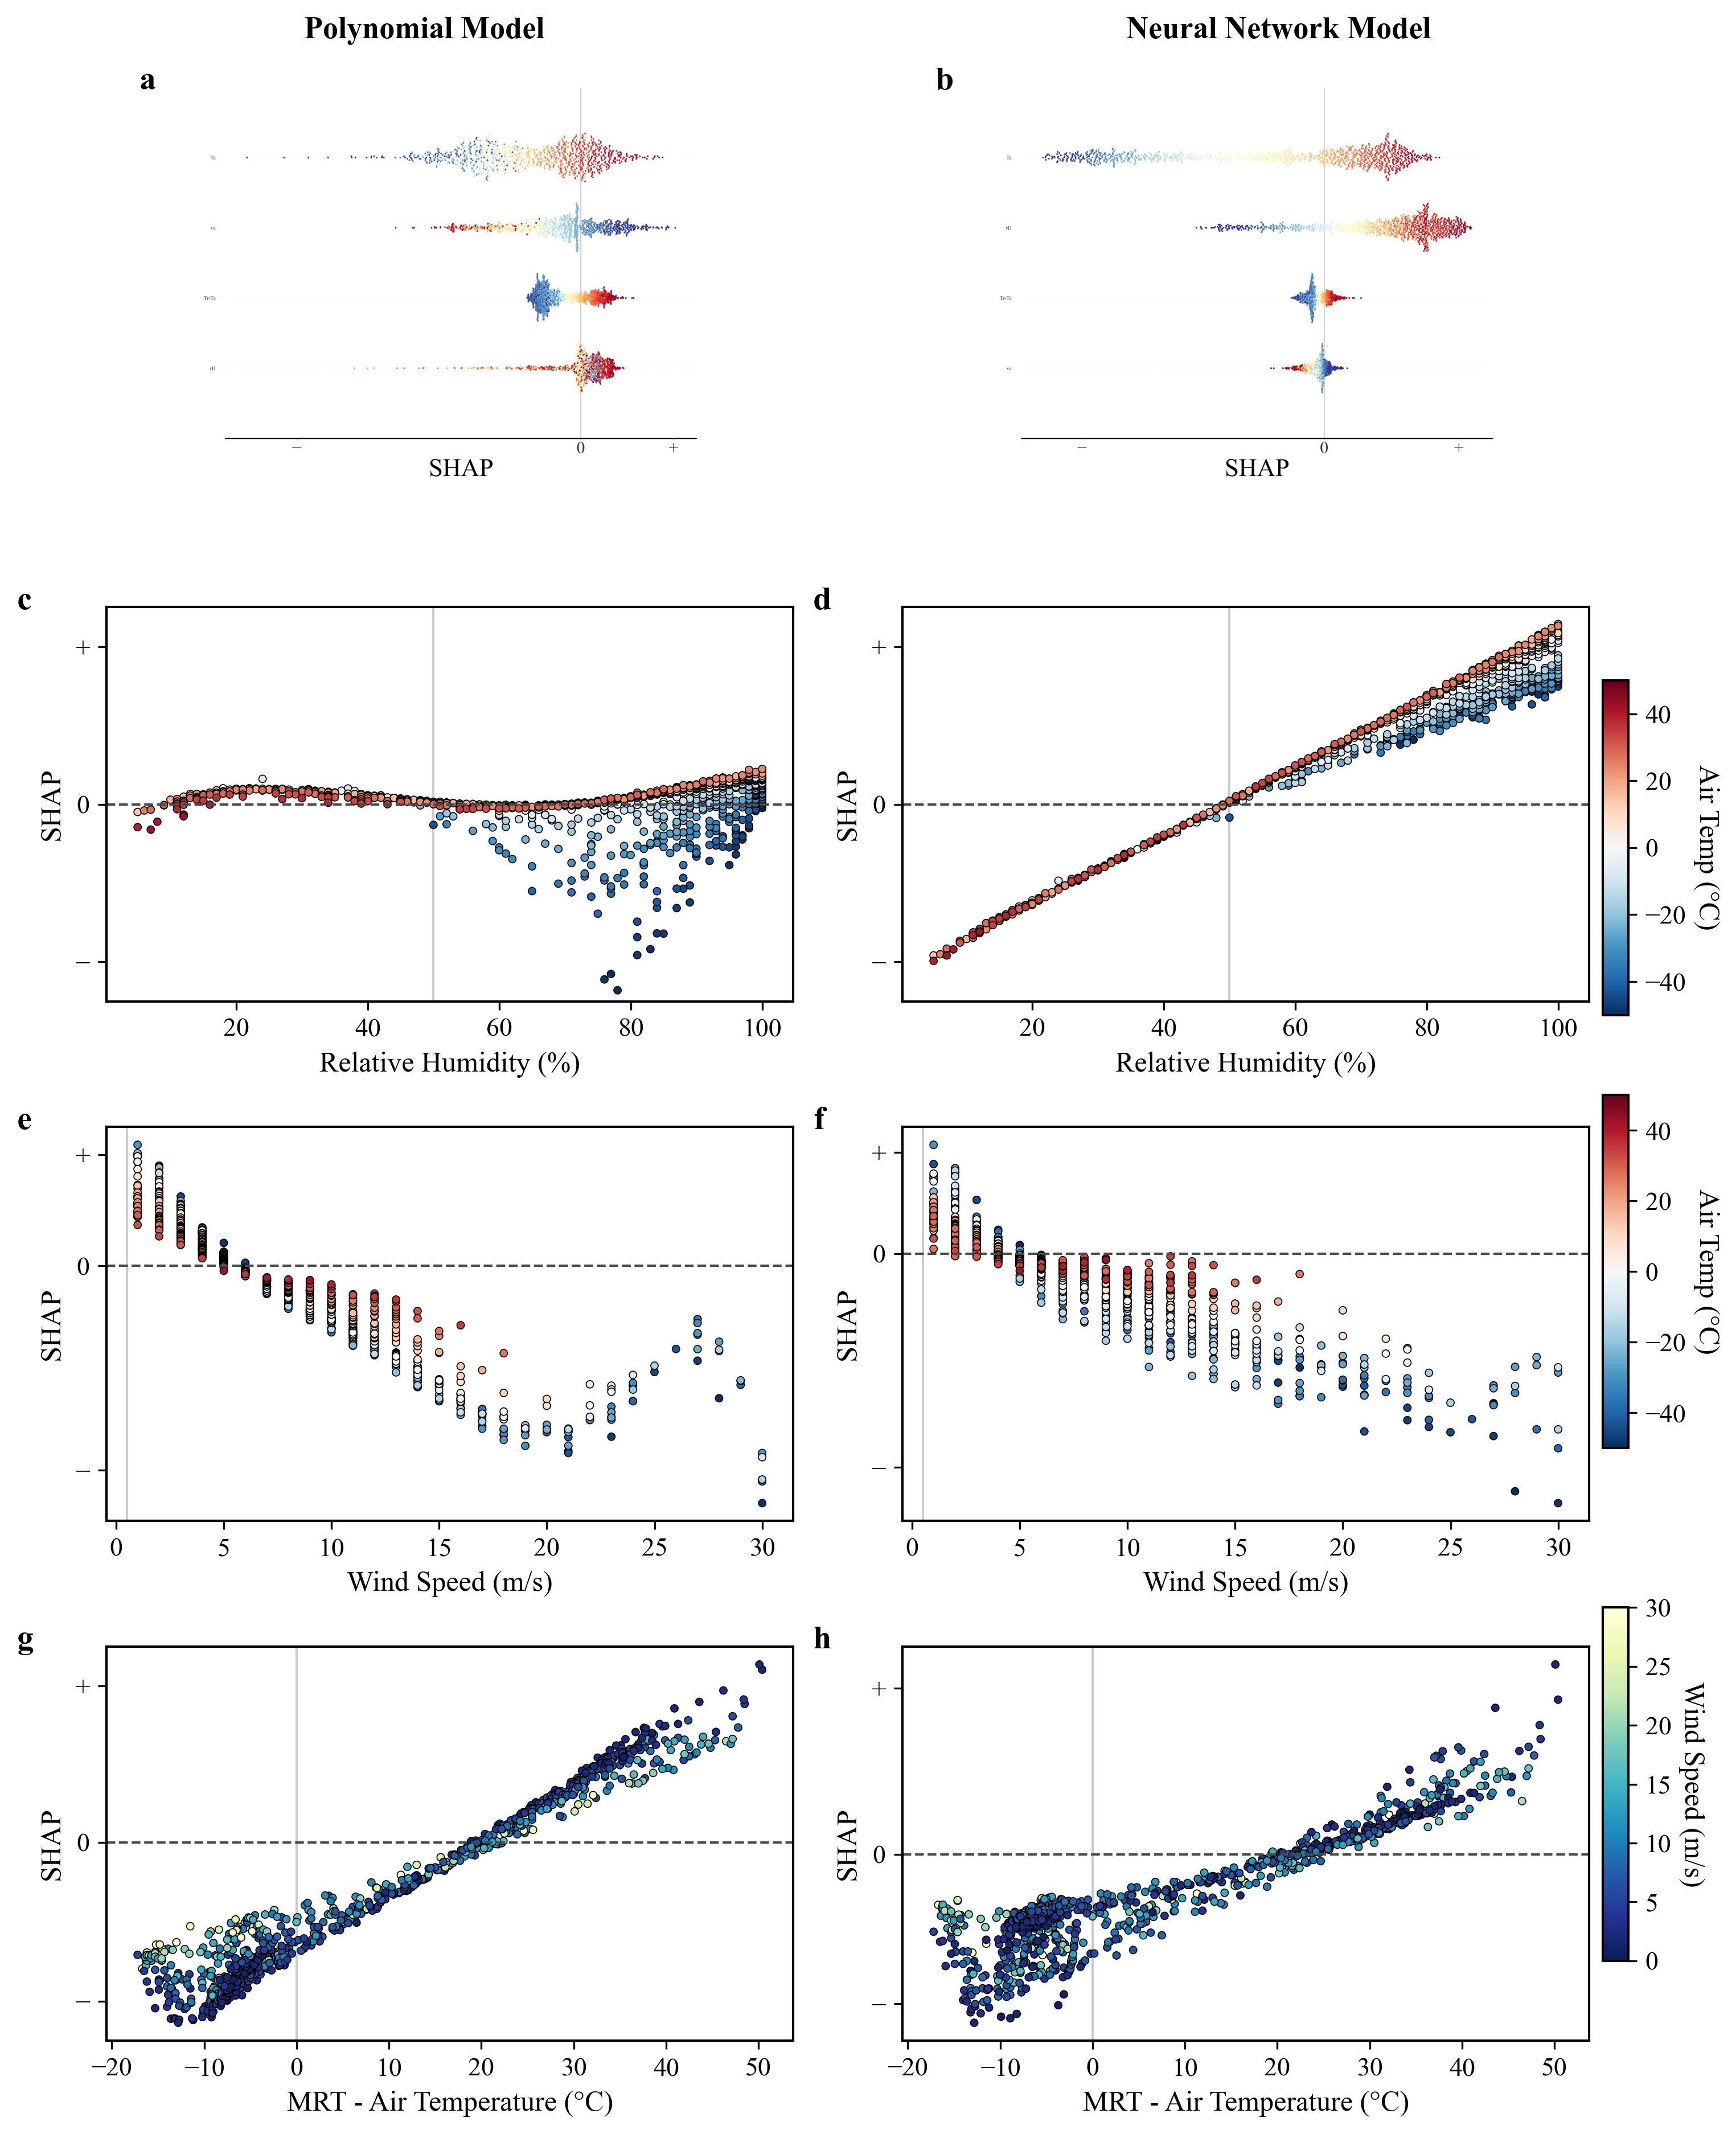

Saved: ../figures/shap_combined.png and ../figures/shap_combined.pdf


In [116]:
import shap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib import cm

# ---------- Publication-quality rc settings ----------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------- Simple helper to add a colorbar for a single axis ----------
def simple_add_cbar(fig, ax, mappable, side='right', size=0.02, pad=0.04, shrink=1.0, y_offset=0.0, **cbar_kwargs):
    pos = ax.get_position()
    if side == 'right':
        x = pos.x1 + pad
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'left':
        x = pos.x0 - pad - size
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'top':
        y = pos.y1 + pad
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    elif side == 'bottom':
        y = pos.y0 - pad - size
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    else:
        raise ValueError("side must be 'right','left','top' or 'bottom'")

    cbar = fig.colorbar(mappable, cax=cax, orientation=orientation, **cbar_kwargs)
    return cbar, cax

# ---------- Figure setup ----------
# Reserve one image row + three dependence rows -> 4 rows x 2 cols
fig_w, fig_h = 10, 13   # slightly taller to fit the image row
fig, axs = plt.subplots(4, 2, figsize=(fig_w, fig_h), squeeze=True)

# ---------- Insert saved beeswarm PNGs into the top row ----------
# Ensure these files exist (from the separate save step)
beeswarm_lr_path = "../figures/shap_beeswarm_lr.png"
beeswarm_nn_path = "../figures/shap_beeswarm_nn.png"

# left top
img_lr = mpimg.imread(beeswarm_lr_path)
axs[0, 0].imshow(img_lr)
axs[0, 0].axis('off')

# right top
img_nn = mpimg.imread(beeswarm_nn_path)
axs[0, 1].imshow(img_nn)
axs[0, 1].axis('off')

# place column titles above the top row images
fig.text(0.25, 0.96, 'Polynomial Model', ha='center', fontsize=13, fontweight='bold')
fig.text(0.75, 0.96, 'Neural Network Model', ha='center', fontsize=13, fontweight='bold')

# ---------- Feature names and settings for dependence plots (rows 1..3) ----------
feature_names = ['Ta', 'Tr-Ta', 'va', 'rH']

# These map to axs[1,*], axs[2,*], axs[3,*]
plot_configs = [
    (3, 0, "Air Temp (°C)", "Relative Humidity (%)", 50),      # dependence row 1 -> axs[1,*]
    (2, 0, "Air Temp (°C)", "Wind Speed (m/s)", 0.5),          # dependence row 2 -> axs[2,*]
    (1, 2, "Wind Speed (m/s)", "MRT - Air Temperature (°C)", 0) # dependence row 3 -> axs[3,*]
]

point_size = 10
alpha_val = 1

row_cmap_settings = [
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),
    (plt.get_cmap('YlGnBu_r'), mcolors.Normalize(vmin=0, vmax=30))
]

# ---------- Colorbar specs for the dependence rows (axs[1], axs[2], axs[3]) ----------
# Change y_offset to nudge colorbars up (>0) or down (<0)
colorbar_specs = [
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.90, 'y_offset':  0.00},  # axs[1,*]
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset':  0.01},  # axs[2,*]
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset': -0.02}   # axs[3,*]
]

# ---------- Dependence plots ----------
for local_row_idx, (feature_idx, color_idx, color_label, feature_label, ref_value) in enumerate(plot_configs):
    row_idx = local_row_idx + 1  # shift because top row (0) is the beeswarm images
    cmap, norm = row_cmap_settings[local_row_idx]
    row_scatter = None

    for col in range(2):
        ax = axs[row_idx, col]

        shap_vals = shap_values_lr if col == 0 else shap_values_nn
        color_data = X_test.iloc[:, color_idx].values

        scatter = ax.scatter(
            X_test.iloc[:, feature_idx],
            shap_vals.values[:, feature_idx],
            c=color_data,
            s=point_size,
            alpha=alpha_val,
            cmap=cmap,
            norm=norm,
            linewidths=0.4,
            edgecolors='black',
            rasterized=True
        )

        ax.set_xlabel(feature_label, fontsize=12)
        ax.set_ylabel('SHAP', fontsize=12)
        ax.tick_params(labelsize=11)
        ax.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1.0)
        ax.axvline(ref_value, color='gray', linestyle='-', linewidth=1, alpha=0.4, zorder=-1)

        # maintain symmetry like your original for the first dependence row
        if row_idx == 1:
            ylim = ax.get_ylim()
            max_abs = max(abs(ylim[0]), abs(ylim[1]))
            ax.set_ylim(-max_abs, max_abs)

        ylim = ax.get_ylim()
        y_max = ylim[1]; y_min = ylim[0]
        pos_tick = y_max * 0.8 if y_max > 0 else 0.1
        neg_tick = y_min * 0.8 if y_min < 0 else -0.1
        ax.set_yticks([neg_tick, 0, pos_tick])
        ax.set_yticklabels(['−', '0', '+'])

        # capture scatter from right column for colorbar
        if col == 1:
            row_scatter = scatter
            row_color_label = color_label

    # add colorbar for this dependence row
    spec = colorbar_specs[local_row_idx]
    cbar, cax = simple_add_cbar(
        fig,
        axs[row_idx, 1],    # reference axis to position colorbar beside
        row_scatter,
        side=spec.get('side', 'right'),
        size=spec.get('size', 0.02),
        pad=spec.get('pad', 0.04),
        shrink=spec.get('shrink', 1.0),
        y_offset=spec.get('y_offset', 0.0)
    )
    if spec.get('side', 'right') in ('right', 'left'):
        cbar.set_label(row_color_label, fontsize=12, rotation=270, labelpad=14)
    else:
        cbar.set_label(row_color_label, fontsize=12, rotation=0, labelpad=6)
    cbar.ax.tick_params(labelsize=11)

# ---------- Panel labels (start with 'a') ----------
# 4 rows x 2 cols => 8 panels -> labels a..j
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
for idx, ax in enumerate(axs.flat):
    # skip labeling the image axes with a/b; still keep labels sequentially for visual figure reading
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# ---------- Final layout & save ----------
plt.tight_layout(rect=[0, 0.01, 0.95, 0.96])  # leave top margin for titles
out_base = "../figures/shap_combined"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)
plt.show()
print(f"Saved: {out_base}.png and {out_base}.pdf")

# Reset rc to defaults
plt.rcParams.update(plt.rcParamsDefault)


C:\Users\nerc-user\AppData\Local\Temp\ipykernel_24252\194274385.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 0.95, 0.98])


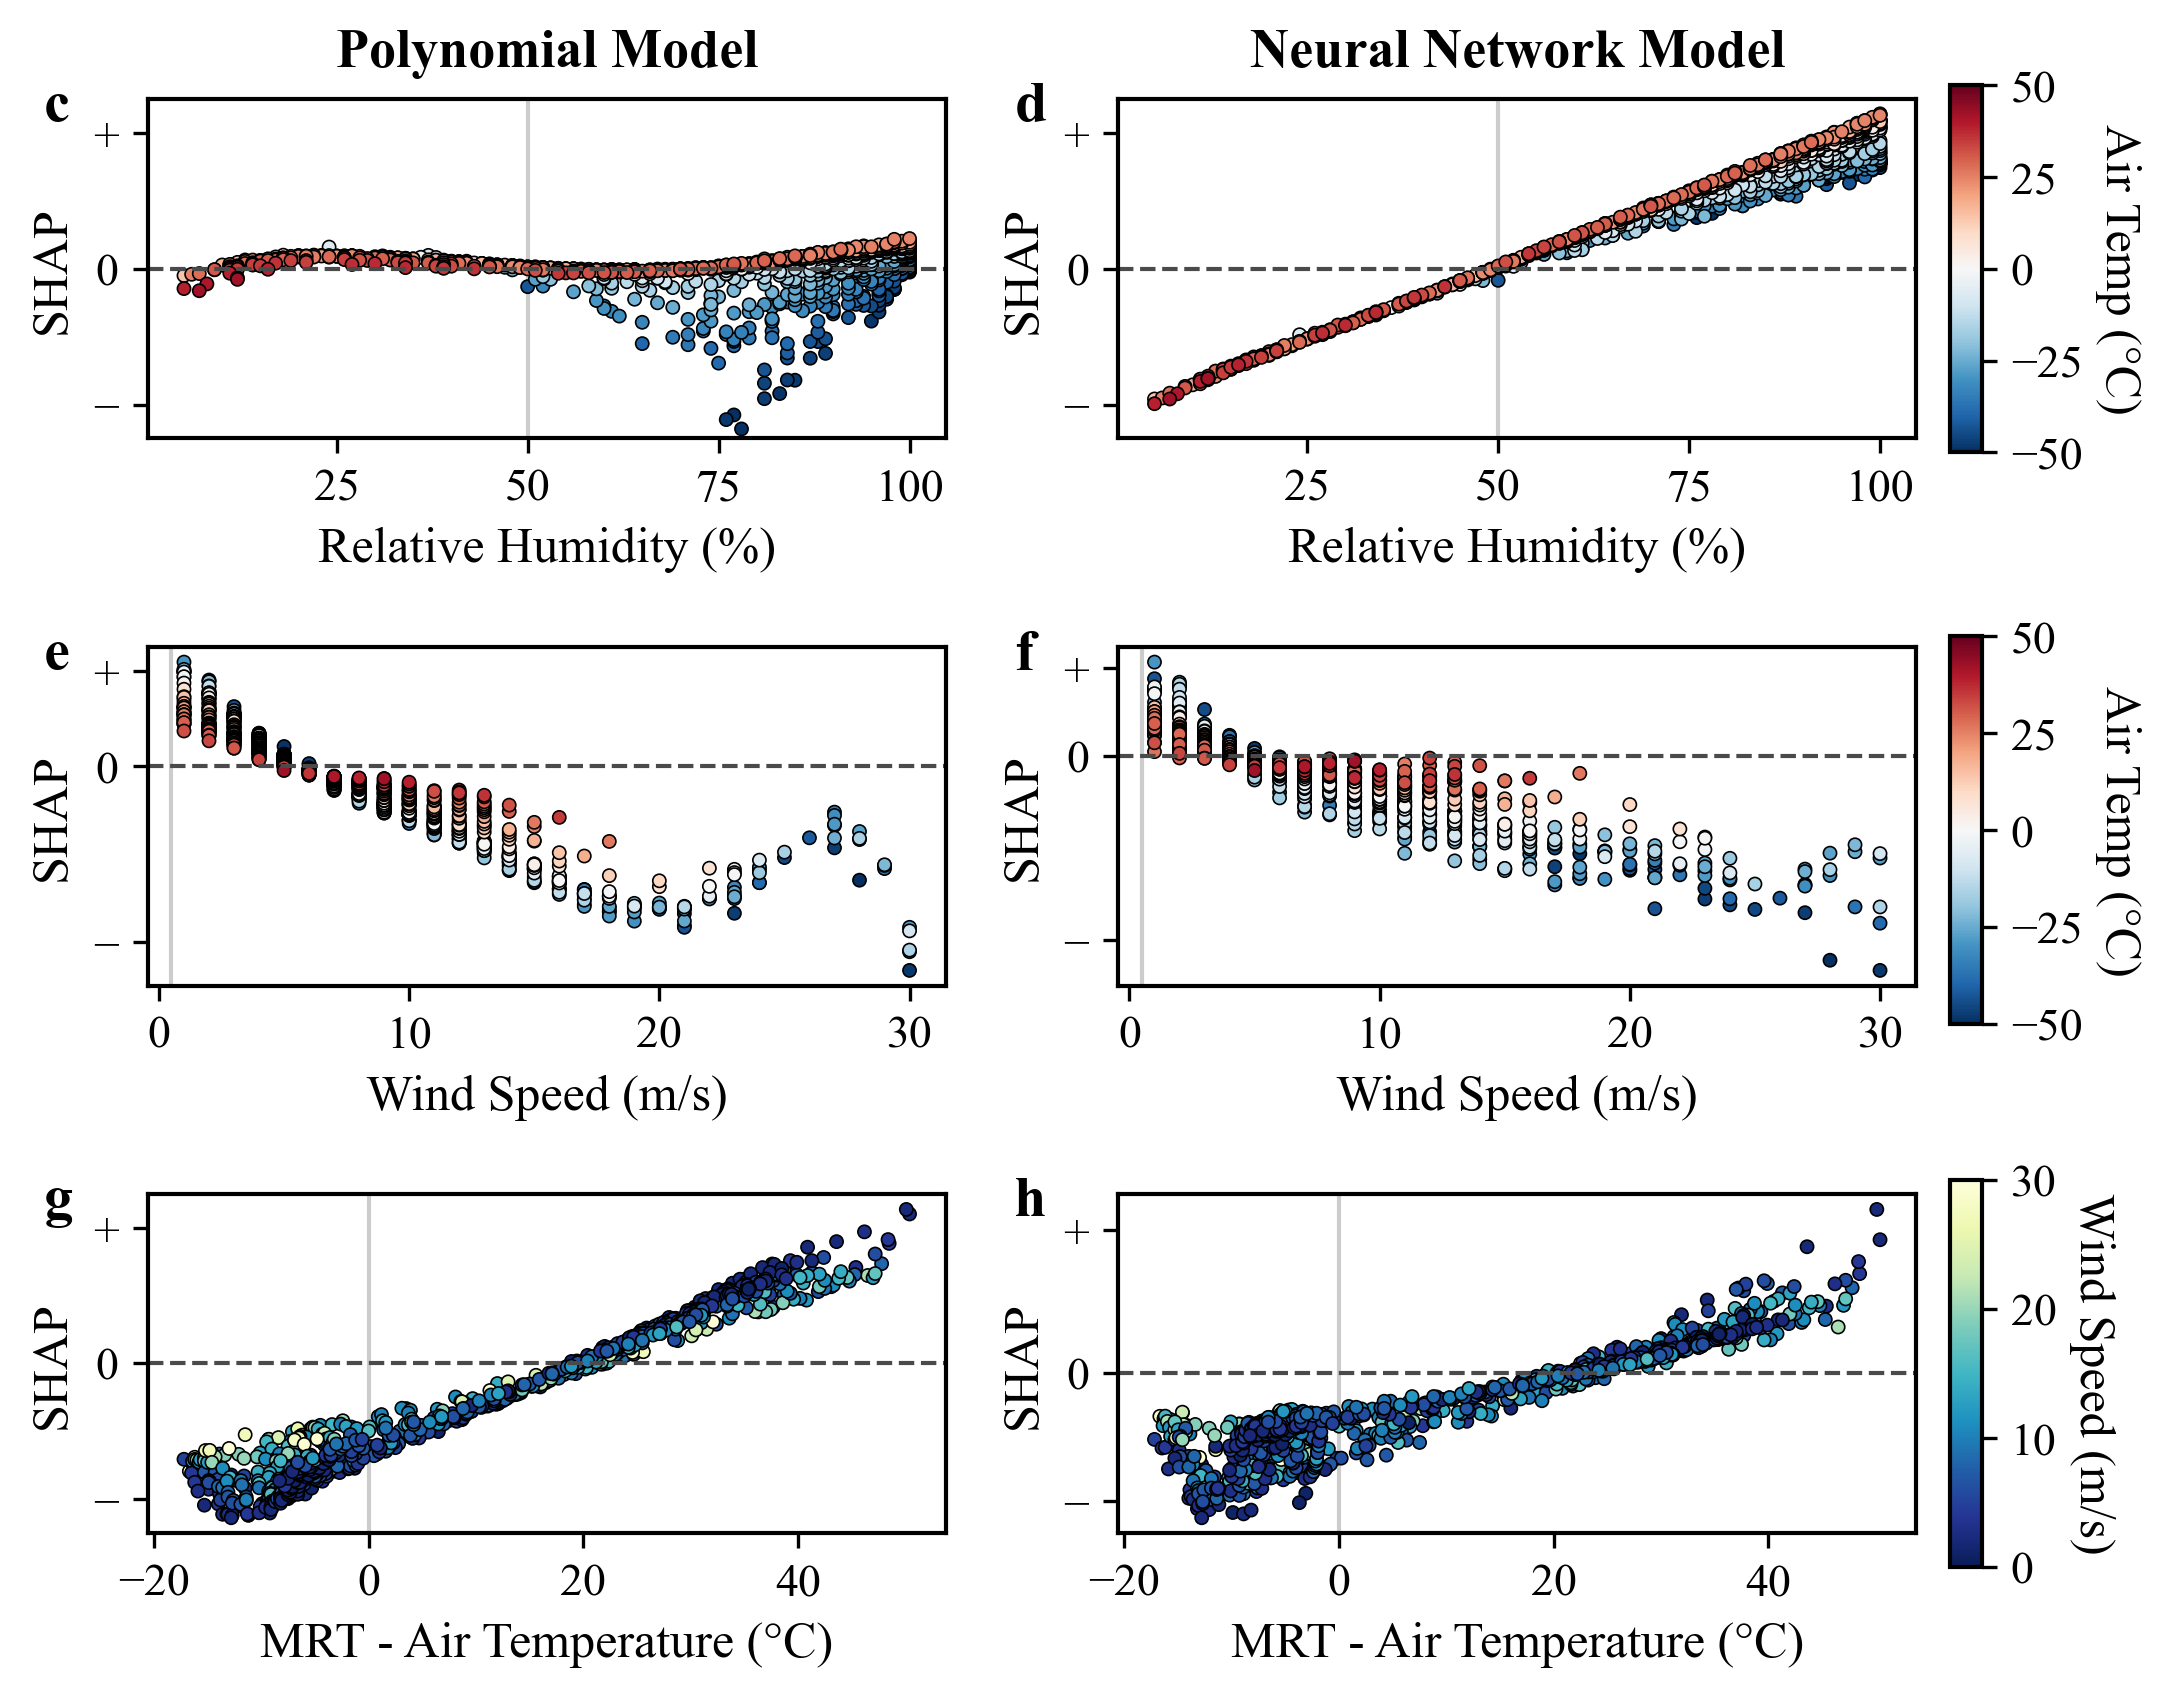

Saved: ../figures/shap_dependence_analysis.png and ../figures/shap_dependence_analysis.pdf


In [81]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib import cm

# ---------- Publication-quality rc settings ----------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------- Simple helper to add a colorbar for a single axis ----------
def simple_add_cbar(fig, ax, mappable, side='right', size=0.02, pad=0.04, shrink=1.0, y_offset=0.0, **cbar_kwargs):
    """
    Very small helper to place a colorbar next to `ax`.
    - side: 'right'|'left'|'top'|'bottom' (we only use 'right' here)
    - size: thickness in figure fraction (width for vertical)
    - pad: horizontal gap from axis edge in figure fraction (applied to pos.x1)
    - shrink: fraction of axis height to use for colorbar length
    - y_offset: additional figure-fraction offset added to pos.y0 (positive moves up)
    Returns the colorbar instance.
    """
    pos = ax.get_position()
    if side == 'right':
        x = pos.x1 + pad
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'left':
        x = pos.x0 - pad - size
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'top':
        y = pos.y1 + pad
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    elif side == 'bottom':
        y = pos.y0 - pad - size
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    else:
        raise ValueError("side must be 'right','left','top' or 'bottom'")

    cbar = fig.colorbar(mappable, cax=cax, orientation=orientation, **cbar_kwargs)
    return cbar, cax

# ---------- Figure setup ----------
fig_w, fig_h = 7.0, 6.0
fig, axs = plt.subplots(3, 2, figsize=(fig_w, fig_h), squeeze=True)

# ---------- Feature names and settings ----------
feature_names = ['Ta', 'Tr-Ta', 'va', 'rH']

plot_configs = [
    (3, 0, "Air Temp (°C)", "Relative Humidity (%)", 50),      # Row 0
    (2, 0, "Air Temp (°C)", "Wind Speed (m/s)", 0.5),          # Row 1
    (1, 2, "Wind Speed (m/s)", "MRT - Air Temperature (°C)", 0) # Row 2
]

point_size = 10
alpha_val = 1

row_cmap_settings = [
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),
    (plt.get_cmap('YlGnBu_r'), mcolors.Normalize(vmin=0, vmax=30))
]

# ---------- Colorbar specs by row (easy to tweak per-row) ----------
# change 'y_offset' to move the bar up (>0) or down (<0) for that row
# units: figure fraction. Typical small nudges: +/- 0.01 .. 0.05
colorbar_specs = [
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.90, 'y_offset':  0.05},  # row 0
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset': 0.01},  # row 1 
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset':  -0.02}   # row 2
]

# ---------- All rows: Dependence plots ----------
for row_idx, (feature_idx, color_idx, color_label, feature_label, ref_value) in enumerate(plot_configs):
    cmap, norm = row_cmap_settings[row_idx]
    row_scatter = None

    for col in range(2):
        ax = axs[row_idx, col]

        shap_vals = shap_values_lr if col == 0 else shap_values_nn
        color_data = X_test.iloc[:, color_idx].values

        scatter = ax.scatter(
            X_test.iloc[:, feature_idx],
            shap_vals.values[:, feature_idx],
            c=color_data,
            s=point_size,
            alpha=alpha_val,
            cmap=cmap,
            norm=norm,
            linewidths=0.4,
            edgecolors='black',
            rasterized=True
        )

        ax.set_xlabel(feature_label, fontsize=12)
        ax.set_ylabel('SHAP', fontsize=12)
        ax.tick_params(labelsize=11)
        ax.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1.0)
        ax.axvline(ref_value, color='gray', linestyle='-', linewidth=1, alpha=0.4, zorder=-1)

        if row_idx == 0:
            ylim = ax.get_ylim()
            max_abs = max(abs(ylim[0]), abs(ylim[1]))
            ax.set_ylim(-max_abs, max_abs)

        ylim = ax.get_ylim()
        y_max = ylim[1]; y_min = ylim[0]
        pos_tick = y_max * 0.8 if y_max > 0 else 0.1
        neg_tick = y_min * 0.8 if y_min < 0 else -0.1
        ax.set_yticks([neg_tick, 0, pos_tick])
        ax.set_yticklabels(['−', '0', '+'])

        # pick scatter to be used for colorbar (use the RIGHT column's scatter)
        if col == 1:
            row_scatter = scatter
            row_color_label = color_label

    # Add colorbar using the per-row spec.
    spec = colorbar_specs[row_idx]
    # Use the right subplot (axs[row_idx, 1]) as reference axis for placement
    cbar, cax = simple_add_cbar(
        fig,
        axs[row_idx, 1],
        row_scatter,
        side=spec.get('side', 'right'),
        size=spec.get('size', 0.02),
        pad=spec.get('pad', 0.04),
        shrink=spec.get('shrink', 1.0),
        y_offset=spec.get('y_offset', 0.0)
    )

    # label rotation/placement depending on side
    if spec.get('side', 'right') in ('right', 'left'):
        cbar.set_label(row_color_label, fontsize=12, rotation=270, labelpad=14)
    else:
        cbar.set_label(row_color_label, fontsize=12, rotation=0, labelpad=6)
    cbar.ax.tick_params(labelsize=11)

# ---------- Panel labels (now starting from 'c') ----------
panel_labels = ['c', 'd', 'e', 'f', 'g', 'h']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# ---------- Column titles ----------
axs[0, 0].set_title('Polynomial Model', fontsize=13, pad=8, fontweight='bold')
axs[0, 1].set_title('Neural Network Model', fontsize=13, pad=8, fontweight='bold')

# ---------- Final layout & save ----------
plt.tight_layout(rect=[0, 0.01, 0.95, 0.98])
out_base = "../figures/shap_dependence_analysis"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)
plt.show()
print(f"Saved: {out_base}.png and {out_base}.pdf")

# Reset to defaults
plt.rcParams.update(plt.rcParamsDefault)


In [82]:
import matplotlib.image as mpimg


C:\Users\nerc-user\AppData\Local\Temp\ipykernel_24252\1793490408.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 0.95, 0.96])  # leave a little top margin for titles


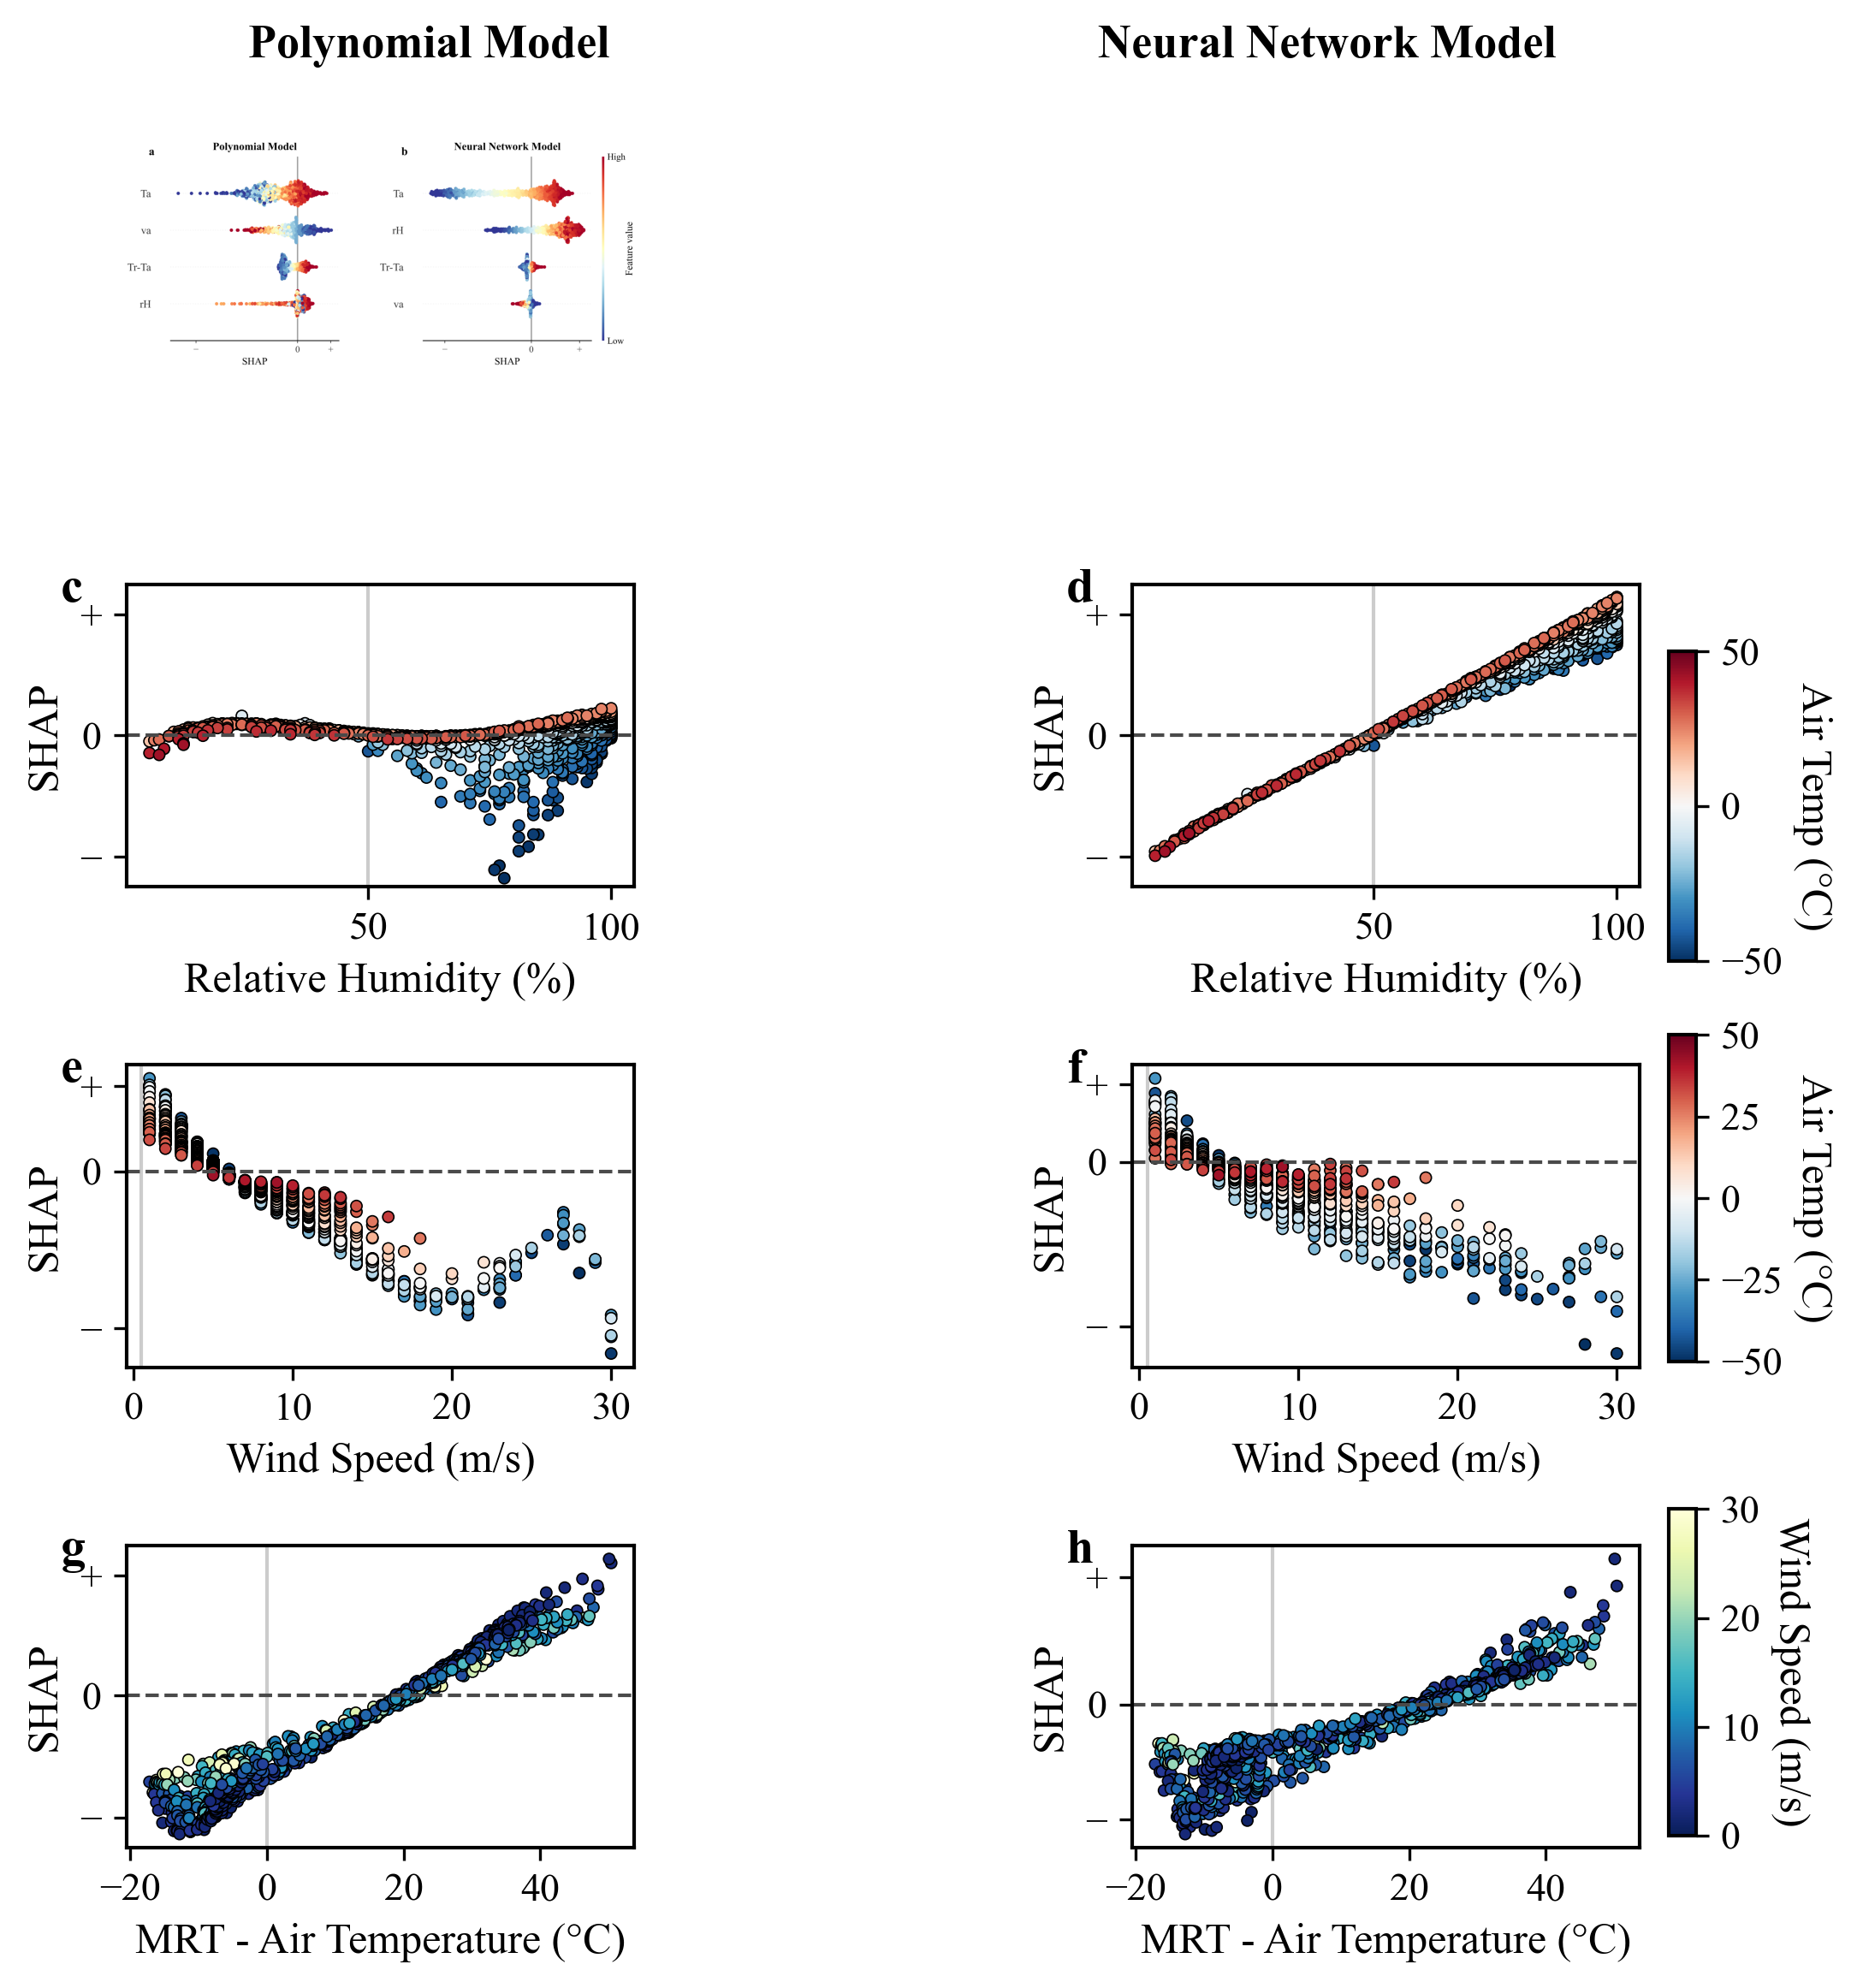

Saved: ../figures/shap_combined.png and ../figures/shap_combined.pdf


In [84]:
import shap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib import cm

# ---------- Publication-quality rc settings ----------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------- Simple helper to add a colorbar for a single axis ----------
def simple_add_cbar(fig, ax, mappable, side='right', size=0.02, pad=0.04, shrink=1.0, y_offset=0.0, **cbar_kwargs):
    pos = ax.get_position()
    if side == 'right':
        x = pos.x1 + pad
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'left':
        x = pos.x0 - pad - size
        height = pos.height * shrink
        y = pos.y0 + y_offset + (pos.height - height) / 2.0
        cax = fig.add_axes([x, y, size, height])
        orientation = 'vertical'
    elif side == 'top':
        y = pos.y1 + pad
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    elif side == 'bottom':
        y = pos.y0 - pad - size
        width = pos.width * shrink
        x = pos.x0 + (pos.width - width) / 2.0
        cax = fig.add_axes([x, y, width, size])
        orientation = 'horizontal'
    else:
        raise ValueError("side must be 'right','left','top' or 'bottom'")

    cbar = fig.colorbar(mappable, cax=cax, orientation=orientation, **cbar_kwargs)
    return cbar, cax

# ---------- Figure setup ----------
# Make room for one image row + three dependence rows -> 4 rows x 2 cols
fig_w, fig_h = 7.0, 8.0   # increased height for image row
fig, axs = plt.subplots(4, 2, figsize=(fig_w, fig_h), squeeze=True)

# ---------- Insert single beeswarm PNG spanning top row (a & b) ----------
beeswarm_path = "../figures/shap_beeswarm.png"
beeswarm_img = mpimg.imread(beeswarm_path)

# Compute union bbox of axs[0,0] and axs[0,1] and assign to axs[0,0]
pos0 = axs[0, 0].get_position()
pos1 = axs[0, 1].get_position()
union_x0 = pos0.x0
union_y0 = pos0.y0
union_width = pos1.x1 - pos0.x0
union_height = pos0.height
axs[0, 0].set_position([union_x0, union_y0, union_width, union_height])

# Show image on the merged axis and hide ticks
axs[0, 0].imshow(beeswarm_img)
axs[0, 0].axis('off')

# Hide the now-redundant right-top axis
axs[0, 1].set_visible(False)

# Column titles above the image: left and right
fig.text(0.25, 0.96, 'Polynomial Model', ha='center', fontsize=13, fontweight='bold')
fig.text(0.75, 0.96, 'Neural Network Model', ha='center', fontsize=13, fontweight='bold')

# ---------- Feature names and dependence plot settings (rows 1..3) ----------
feature_names = ['Ta', 'Tr-Ta', 'va', 'rH']

plot_configs = [
    (3, 0, "Air Temp (°C)", "Relative Humidity (%)", 50),      # dependence row 1 -> axs[1,*]
    (2, 0, "Air Temp (°C)", "Wind Speed (m/s)", 0.5),          # dependence row 2 -> axs[2,*]
    (1, 2, "Wind Speed (m/s)", "MRT - Air Temperature (°C)", 0) # dependence row 3 -> axs[3,*]
]

point_size = 10
alpha_val = 1

row_cmap_settings = [
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),
    (plt.get_cmap('RdBu_r'), mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)),
    (plt.get_cmap('YlGnBu_r'), mcolors.Normalize(vmin=0, vmax=30))
]

# colorbar specs for the 3 dependence rows (axs[1], axs[2], axs[3])
colorbar_specs = [
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.90, 'y_offset':  0.00},  # axs[1,*]
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset': 0.01},   # axs[2,*]
    {'side': 'right', 'size': 0.015, 'pad': 0.04, 'shrink': 0.95, 'y_offset': -0.02}   # axs[3,*]
]

# ---------- Dependence plots ----------
for local_row_idx, (feature_idx, color_idx, color_label, feature_label, ref_value) in enumerate(plot_configs):
    row_idx = local_row_idx + 1  # shift down because top row is the image
    cmap, norm = row_cmap_settings[local_row_idx]
    row_scatter = None

    for col in range(2):
        ax = axs[row_idx, col]

        shap_vals = shap_values_lr if col == 0 else shap_values_nn
        color_data = X_test.iloc[:, color_idx].values

        scatter = ax.scatter(
            X_test.iloc[:, feature_idx],
            shap_vals.values[:, feature_idx],
            c=color_data,
            s=point_size,
            alpha=alpha_val,
            cmap=cmap,
            norm=norm,
            linewidths=0.4,
            edgecolors='black',
            rasterized=True
        )

        ax.set_xlabel(feature_label, fontsize=12)
        ax.set_ylabel('SHAP', fontsize=12)
        ax.tick_params(labelsize=11)
        ax.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1.0)
        ax.axvline(ref_value, color='gray', linestyle='-', linewidth=1, alpha=0.4, zorder=-1)

        if row_idx == 1:
            ylim = ax.get_ylim()
            max_abs = max(abs(ylim[0]), abs(ylim[1]))
            ax.set_ylim(-max_abs, max_abs)

        ylim = ax.get_ylim()
        y_max = ylim[1]; y_min = ylim[0]
        pos_tick = y_max * 0.8 if y_max > 0 else 0.1
        neg_tick = y_min * 0.8 if y_min < 0 else -0.1
        ax.set_yticks([neg_tick, 0, pos_tick])
        ax.set_yticklabels(['−', '0', '+'])

        if col == 1:
            row_scatter = scatter
            row_color_label = color_label

    # Add colorbar for this dependence row
    spec = colorbar_specs[local_row_idx]
    cbar, cax = simple_add_cbar(
        fig,
        axs[row_idx, 1],
        row_scatter,
        side=spec.get('side', 'right'),
        size=spec.get('size', 0.02),
        pad=spec.get('pad', 0.04),
        shrink=spec.get('shrink', 1.0),
        y_offset=spec.get('y_offset', 0.0)
    )
    if spec.get('side', 'right') in ('right', 'left'):
        cbar.set_label(row_color_label, fontsize=12, rotation=270, labelpad=14)
    else:
        cbar.set_label(row_color_label, fontsize=12, rotation=0, labelpad=6)
    cbar.ax.tick_params(labelsize=11)

# ---------- Panel labels (start with 'c') ----------
# dependence panels only: 3 rows * 2 cols = 6 panels -> labels 'c'..'h'
panel_labels = ['c', 'd', 'e', 'f', 'g', 'h']
# enumerate over axs[1: , :] flattened
dependence_axes = [axs[r, c] for r in range(1, 4) for c in range(2)]
for idx, ax in enumerate(dependence_axes):
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# ---------- Final layout & save ----------
plt.tight_layout(rect=[0, 0.01, 0.95, 0.96])  # leave a little top margin for titles
out_base = "../figures/shap_combined"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)
plt.show()
print(f"Saved: {out_base}.png and {out_base}.pdf")

# Reset to defaults
plt.rcParams.update(plt.rcParamsDefault)


### SHAP feature importance per point, scatter plots 

In [18]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib import cm
import seaborn as sns

In [ ]:
shap_values_lr

NameError: name 'pred_lr' is not defined

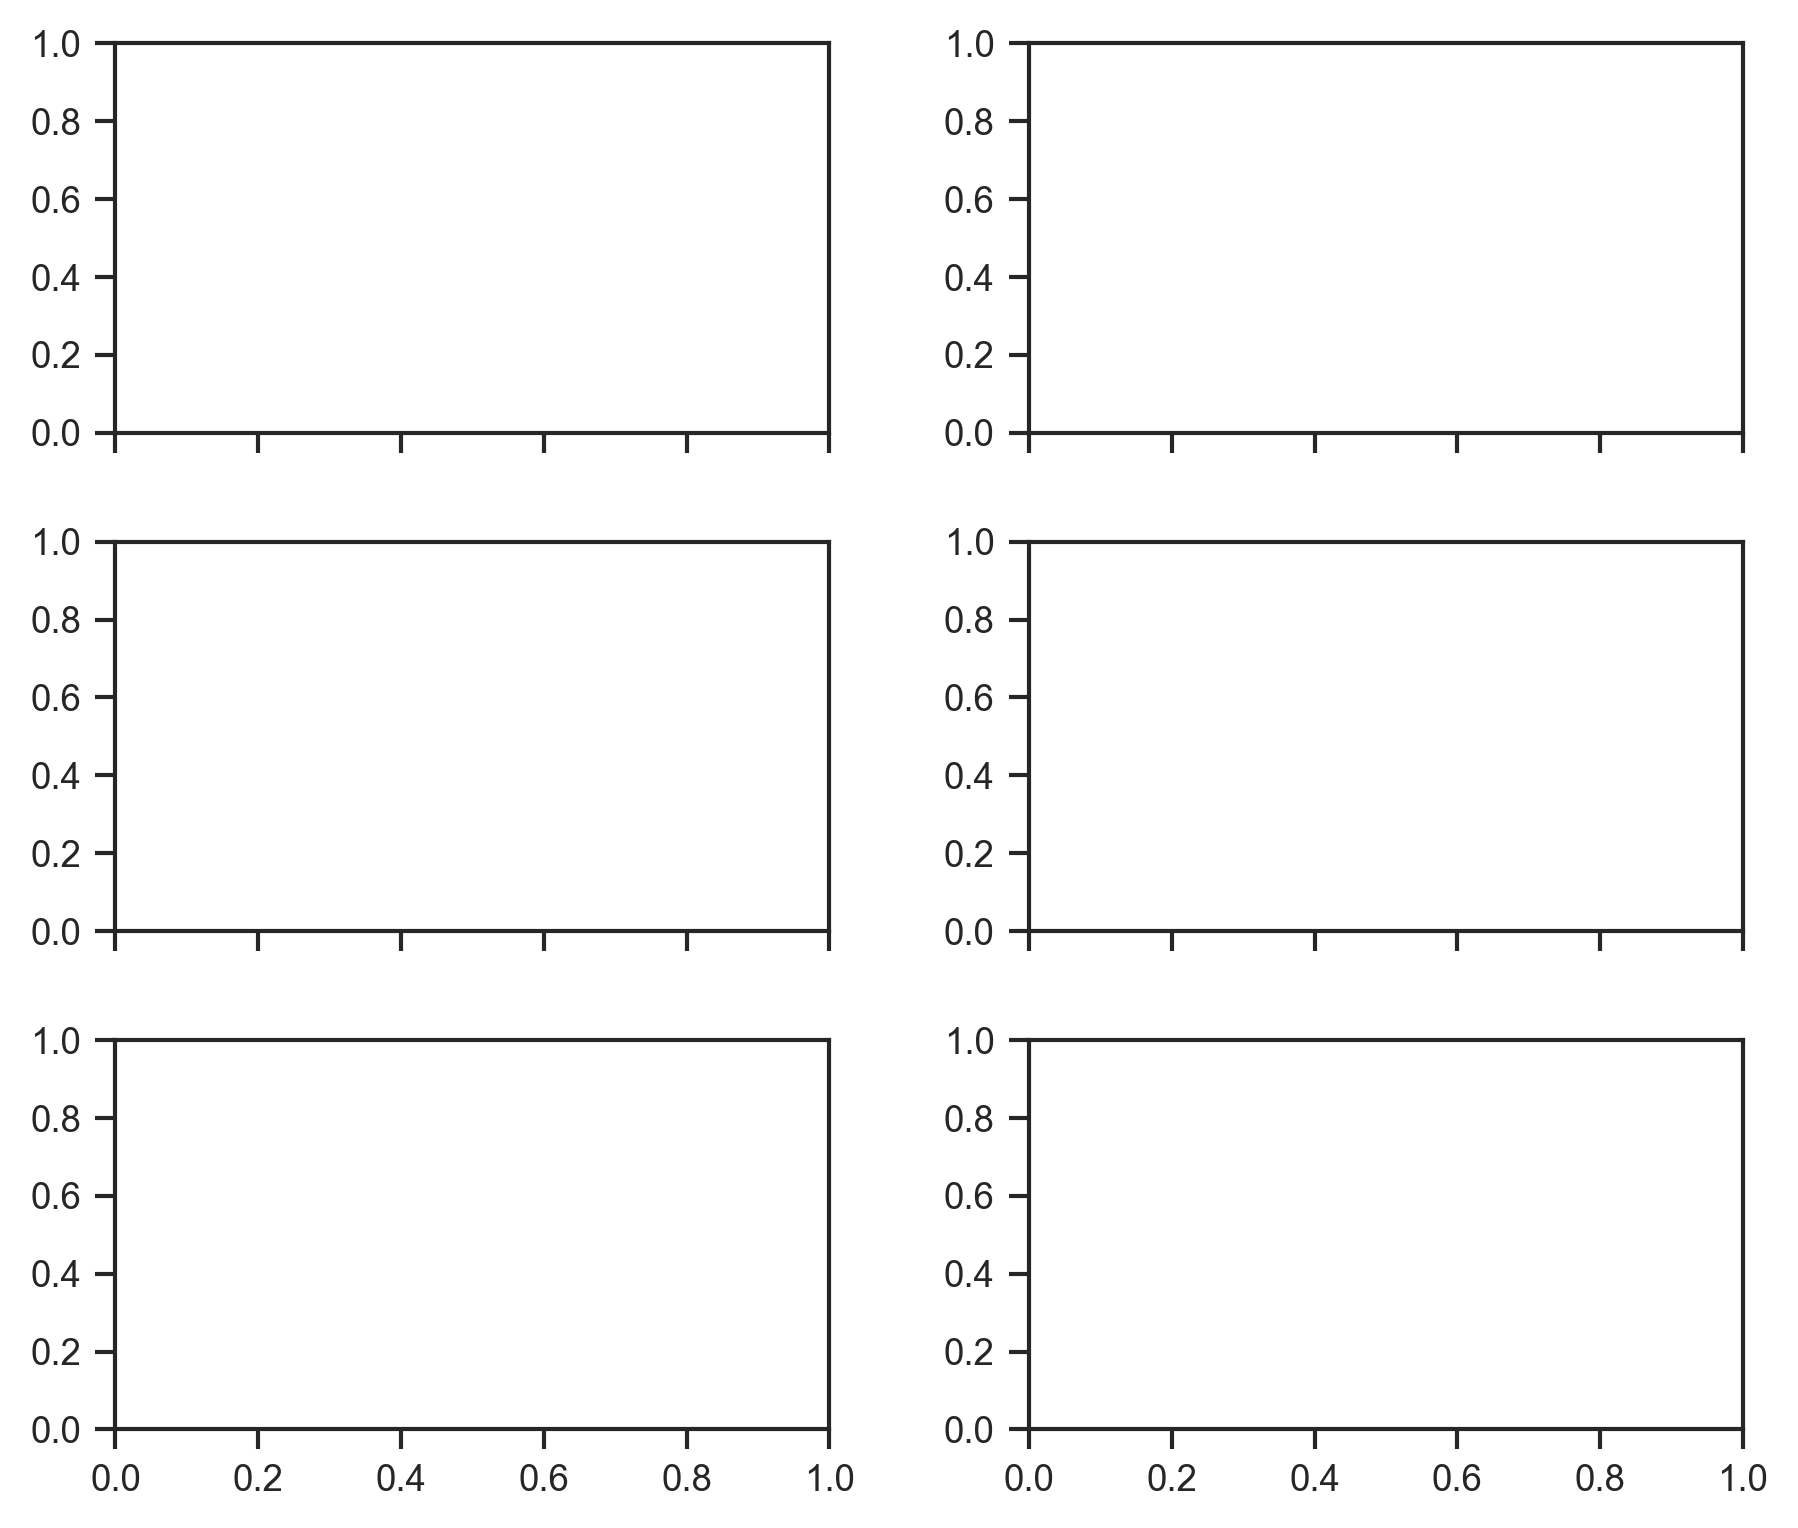

In [ ]:
# ---------- Plot: 3 rows x 2 cols (styled like Plot B) ----------
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.0)

# Figure size tuned toward Plot B aesthetics (a bit more compact)
fig_w, fig_h = 7.0, 7.8  # keep 3 rows but make width like Plot B
fig, axes = plt.subplots(3, 2, figsize=(fig_w, fig_h), sharex='col', squeeze=True)
plt.subplots_adjust(wspace=0.28, hspace=0.28)

ranks = ['1st most important', '2nd most important', '3rd most important']
models = ['Polynomial regression', 'Neural network']
preds = [pred_lr, pred_nn]
resids = [residuals_lr, presiduals_nn]
colors_matrix = [[colors_per_rank_lr[i], colors_per_rank_nn[i]] for i in range(3)]  # rows x cols

# Shared marker/outline settings inspired by Plot B
point_size = 10           # smaller points
outline_linewidth = 0.4   # thin black outline
alpha = 0.72

panel_labels = ['a', 'b', 'c', 'd', 'e', 'f']

# Panel labels (placed before plotting so they sit above)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

for i in range(3):      # rows -> ranks
    for j in range(2):  # cols -> models
        ax = axes[i, j]
        x = preds[j]
        y = resids[j]
        col_colors = colors_matrix[i][j]  # list of colors per sample

        # scatter with black outline, rasterized for vector-friendly PDFs
        ax.scatter(x, y,
                   c=col_colors,
                   s=point_size,
                   alpha=alpha,
                   linewidths=outline_linewidth,
                   edgecolors='black',
                   marker='o',
                   rasterized=True)

        # darker thin dashed zero line like Plot B
        ax.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1.0)

        # Titles and labels
        if i == 0:
            ax.set_title(models[j], fontsize=13, pad=8, fontweight='bold')
        if i == 2:
            ax.set_xlabel("Fiala-UTCI", fontsize=11)
        if j == 0:
            ax.set_ylabel("Error (°C)", fontsize=11)

        # show top/right spines similarly to original intent but keep ticks modest
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.tick_params(axis='both', which='major', labelsize=9)

# ---------- Legend: horizontal, bottom-centered (like Plot B's clean style) ----------
present_features = sorted(set(top1_lr + top2_lr + top3_lr + top1_nn + top2_nn + top3_nn),
                          key=lambda x: unique_features.index(x))
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f,
                      markerfacecolor=feature_to_color[f], markersize=6,
                      markeredgecolor='black')
           for f in present_features]

# place legend to the bottom center (outside axes)
fig.legend(
    handles=handles,
    title="Feature",
    loc="lower center",
    ncol=min(6, max(1, len(handles))),  # reasonable ncols
    frameon=False,
    fontsize=9,
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.03)  # slightly below the figure
)



plt.tight_layout(rect=[0, 0.02, 1, 0.95])
out_base = "shap_residuals_feature_ranks"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01, format='png')
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01, format='pdf')
plt.show()
print(f"Saved: {out_base}.png and {out_base}.pdf")


### Scatter plots

## Plots

In [25]:
test_analysis = test.copy()
test_analysis["nn_predict"] = test_pred
test_analysis["nn_error"] = test_analysis["nn_predict"] - test_analysis["Offset"] 
test_analysis["polynomial_error"] = test_analysis["UTCI_polynomial"] - test_analysis["UTCI"] 

c:\Users\nerc-user\.conda\envs\utci\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_21336\2365131905.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])


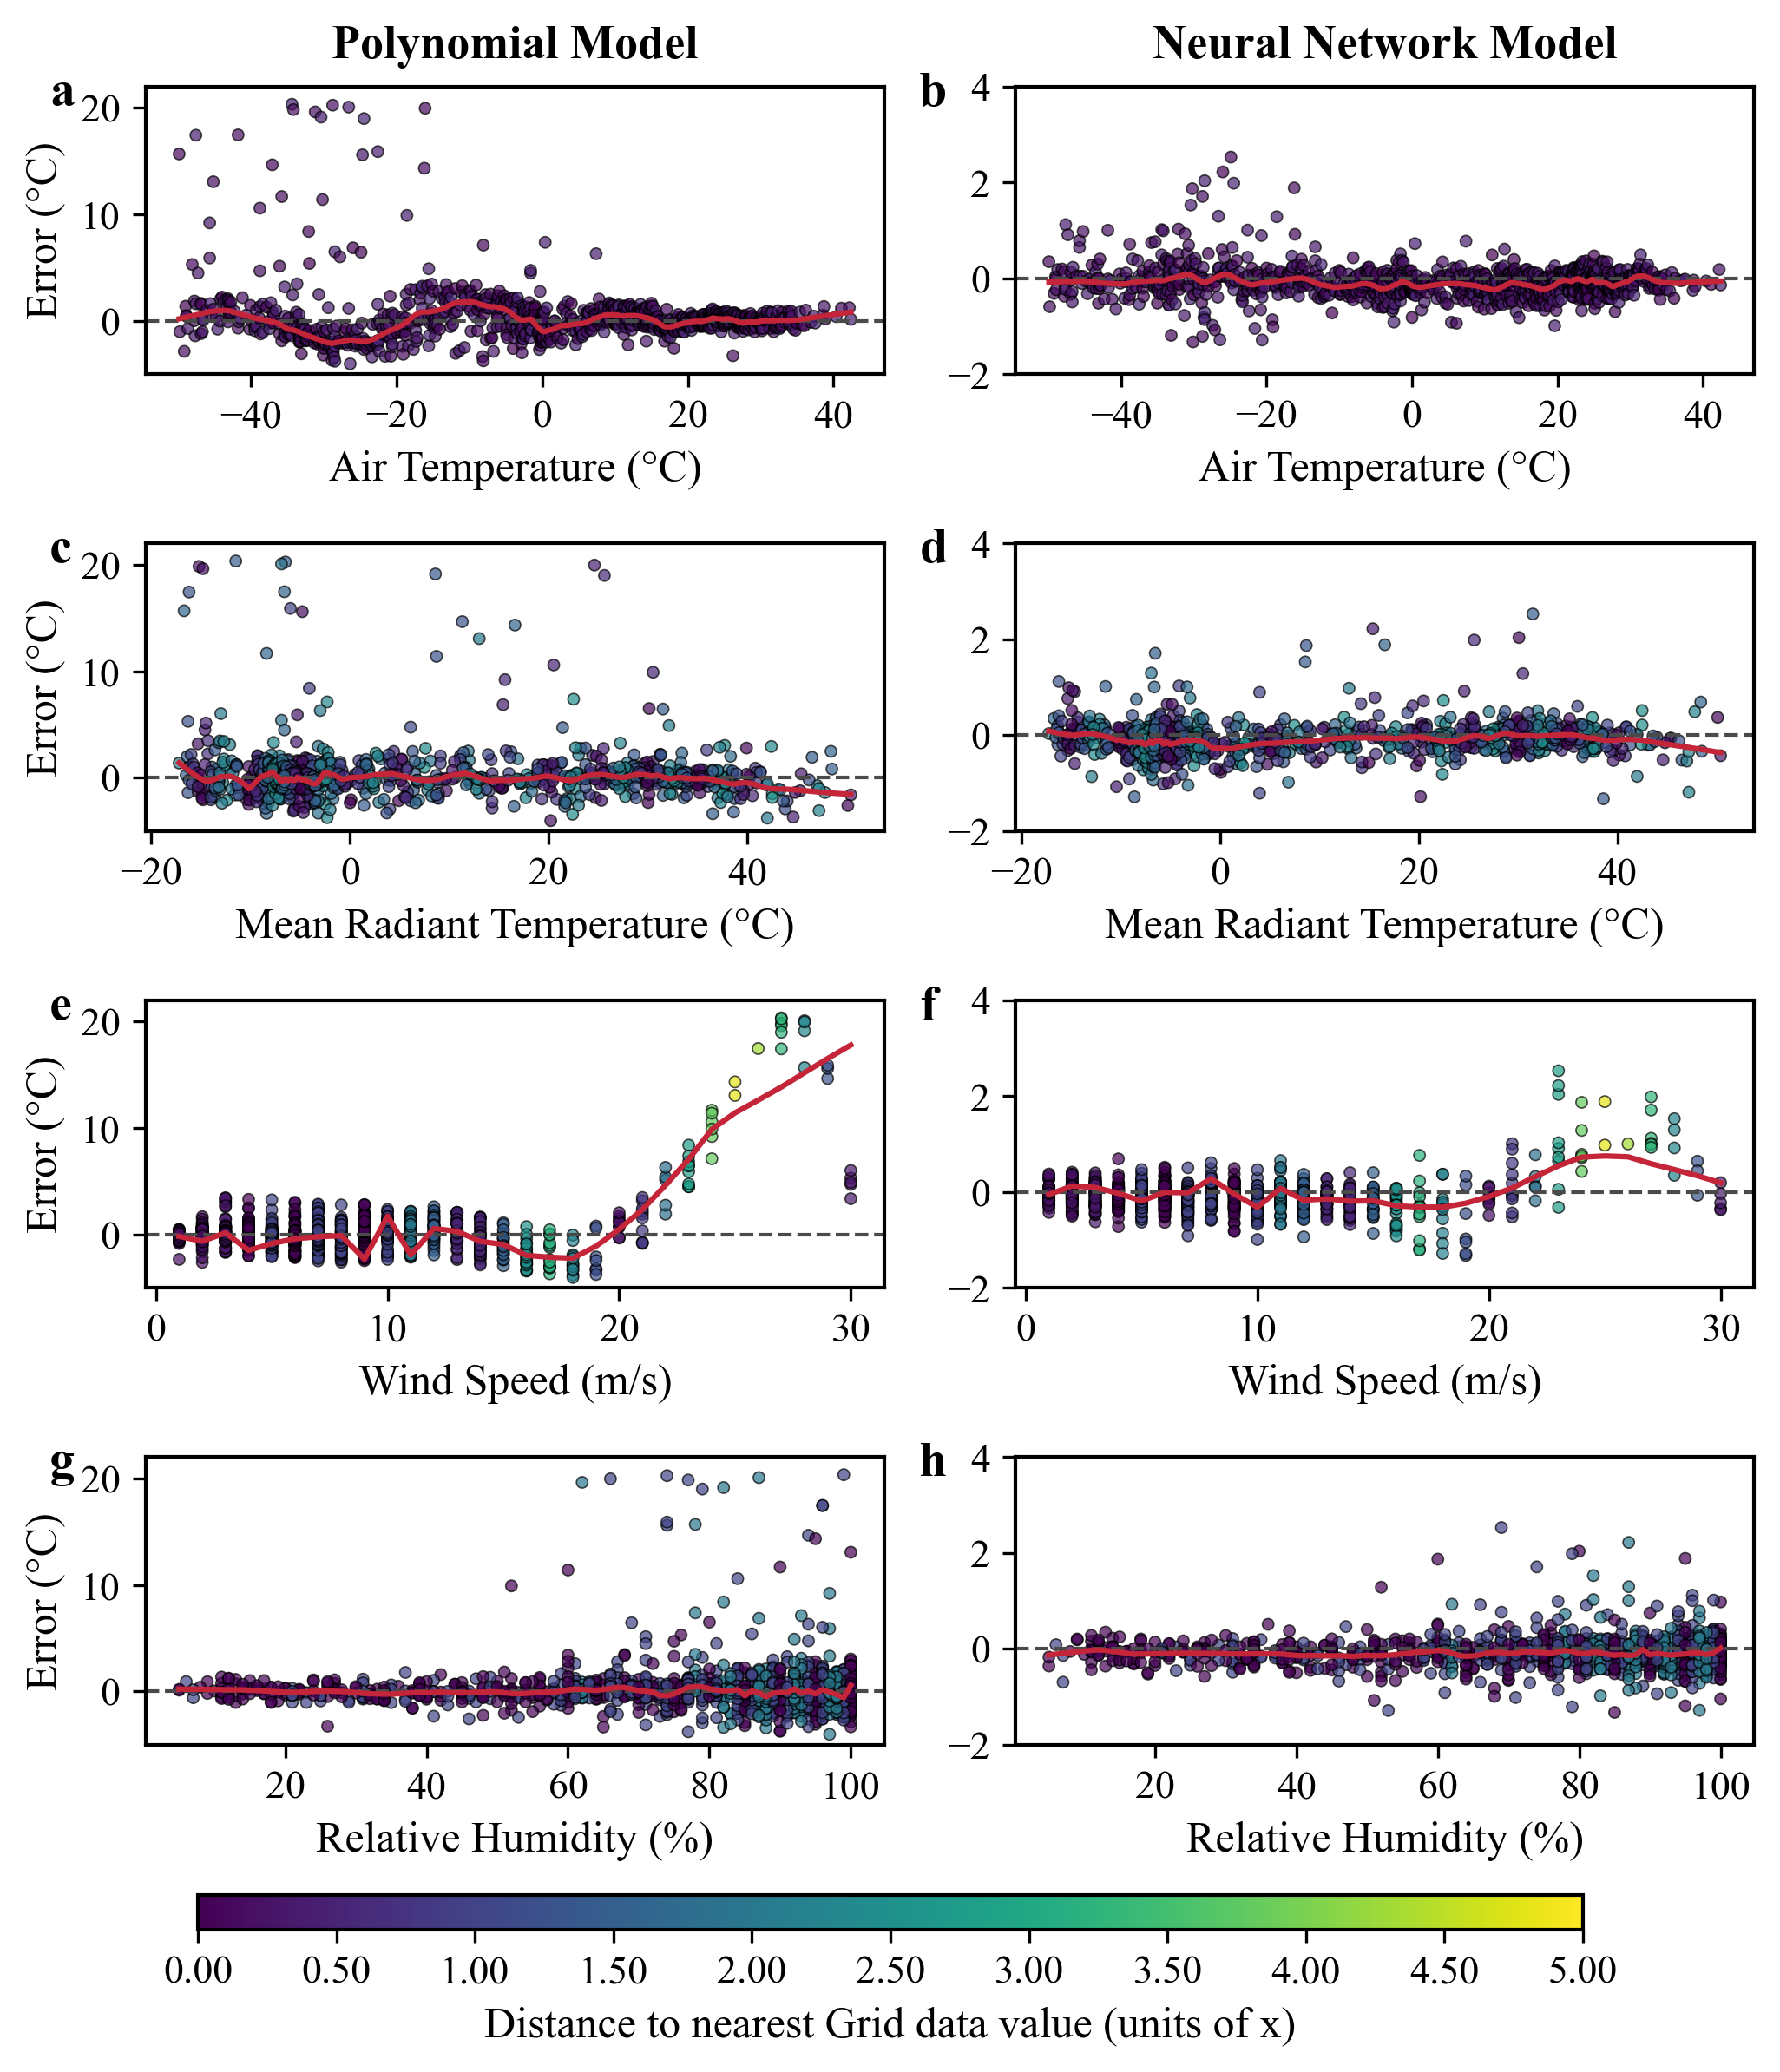

Saved: ../figures/residuals_distance_to_training_colored.png and ../figures/residuals_distance_to_training_colored.pdf


In [46]:

# ---------- Publication-quality rc settings ----------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------- Figure setup ----------
fig_w, fig_h = 7.0, 7.8
fig, axs = plt.subplots(4, 2, figsize=(fig_w, fig_h), squeeze=True)

# ---------- Shared plotting params ----------
point_size = 10
outline_linewidth = 0.9
outline_color = '0.04'
n_bins = 8

# colormap used for distance
cmap = plt.get_cmap('viridis')

# We'll use a continuous Normalize for distances (computed later globally for scale)
norm = None

# LOESS settings
LOESS_FRAC = 0.05
LOESS_IT = 3
MIN_POINTS_FOR_LOESS = 8
FIT_ON_IN_DOMAIN_ONLY = False
IN_DOMAIN_THRESHOLD = 17.0
in_domain_mask = test_analysis['va'] <= IN_DOMAIN_THRESHOLD

# Variables to plot
plot_vars = [
    ('Ta', 'Air Temperature (°C)', 0),
    ('Tr-Ta', 'Mean Radiant Temperature (°C)', 1),
    ('va', 'Wind Speed (m/s)', 2),
    ('rH', 'Relative Humidity (%)', 3),
]

# ---------- Compute distances for each x_var and collect for a global norm ----------
# We'll compute the distances per panel and keep them in a dict
distances_by_var = {}
for x_var, _, _ in plot_vars:
    # get x-values from test_analysis (points to be plotted)
    x_vals = test_analysis[x_var].to_numpy()
    # get the unique reference values from esm4 for this variable
    # if esm4 does not contain the column or has no uniques, handle gracefully
    if x_var not in esm4.columns:
        raise KeyError(f"Column '{x_var}' not present in esm4. Please provide esm4 with that column.")
    uniques = np.asarray(np.unique(esm4[x_var].dropna()))
    if uniques.size == 0:
        # fallback: all distances are NaN
        distances = np.full_like(x_vals, np.nan, dtype=float)
    else:
        # compute min distance to any unique value (vectorized)
        # shape: (n_points, n_uniques)
        # broadcasting abs difference then min along axis=1
        # handle NaNs in x_vals
        valid_mask = ~np.isnan(x_vals)
        distances = np.full_like(x_vals, np.nan, dtype=float)
        if valid_mask.any():
            diffs = np.abs(x_vals[valid_mask][:, None] - uniques[None, :])
            distances[valid_mask] = diffs.min(axis=1)
    distances_by_var[x_var] = distances

# define a global normalization for colourbar so colours are comparable across panels
# ignore NaNs while computing vmin/vmax
all_distances = np.concatenate([d[~np.isnan(d)] for d in distances_by_var.values()]) if distances_by_var else np.array([])
vmin, vmax = all_distances.min(), all_distances.max()
# create Normalize instance used by scatter
norm = mcolors.Normalize(vmin=vmin, vmax=5, clip=True)

# ---------- Shared scatter kwargs template (we will overwrite c) ----------
base_scatter_kwargs = dict(
    cmap=cmap,
    norm=norm,
    s=point_size,
    alpha=0.7,
    linewidths=0.4,
    edgecolors='black',
    marker='o',
    rasterized=True
)

# ---------- Plotting loop ----------
for x_var, x_label, row in plot_vars:
    x = test_analysis[x_var].to_numpy()
    y_poly = test_analysis['polynomial_error'].to_numpy()
    y_nn = test_analysis['nn_error'].to_numpy()
    distances = distances_by_var[x_var]  # precomputed

    # Left: polynomial panel
    axL = axs[row, 0]
    scL = axL.scatter(
        test_analysis[x_var],
        test_analysis['polynomial_error'],
        c=distances,
        **base_scatter_kwargs
    )
    axL.set_xlabel(x_label, fontsize=12)
    axL.set_ylabel('Error (°C)', fontsize=12)
    axL.set_ylim(-5, 22)
    axL.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1)

    # LOESS fit (polynomial)
    if FIT_ON_IN_DOMAIN_ONLY:
        mask = (~np.isnan(x)) & (~np.isnan(y_poly)) & (in_domain_mask.to_numpy())
    else:
        mask = (~np.isnan(x)) & (~np.isnan(y_poly))
    if mask.sum() >= MIN_POINTS_FOR_LOESS:
        x_valid = x[mask]
        y_valid = y_poly[mask]
        loess_res = lowess(y_valid, x_valid, frac=LOESS_FRAC, it=LOESS_IT, return_sorted=True)
        axL.plot(loess_res[:, 0], loess_res[:, 1], color='#C52538', linewidth=1.5, zorder=10)

    # Right: neural network panel
    axR = axs[row, 1]
    scR = axR.scatter(
        test_analysis[x_var],
        test_analysis['nn_error'],
        c=distances,
        **base_scatter_kwargs
    )
    axR.set_xlabel(x_label, fontsize=12)
    axR.set_ylim(-2, 4)
    axR.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1)

    # LOESS fit (nn)
    if FIT_ON_IN_DOMAIN_ONLY:
        mask_nn = (~np.isnan(x)) & (~np.isnan(y_nn)) & (in_domain_mask.to_numpy())
    else:
        mask_nn = (~np.isnan(x)) & (~np.isnan(y_nn))
    if mask_nn.sum() >= MIN_POINTS_FOR_LOESS:
        x_valid_nn = x[mask_nn]
        y_valid_nn = y_nn[mask_nn]
        loess_res_nn = lowess(y_valid_nn, x_valid_nn, frac=LOESS_FRAC, it=LOESS_IT, return_sorted=True)
        axR.plot(loess_res_nn[:, 0], loess_res_nn[:, 1], color='#C52538', linewidth=1.5, zorder=10)


# ---------- Panel labels ----------
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# Titles
axs[0, 0].set_title('Polynomial Model', fontsize=13, pad=8, fontweight='bold')
axs[0, 1].set_title('Neural Network Model', fontsize=13, pad=8, fontweight='bold')

# ---------- Colourbar at the bottom (manual placement) ----------
# Reserve bottom space
fig.subplots_adjust(bottom=0.65)

# add axes for the colourbar: [left, bottom, width, height] in figure coordinates
cax = fig.add_axes([0.12, 0.019, 0.76, 0.017])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# set_array is required for some backends even when using manual cax
sm.set_array([])  
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Distance to nearest Grid data value (units of x)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

# Optional: if you want tick positions at meaningful values, set them here
# e.g., put ticks at [0, (vmax-vmin)/4, (vmax-vmin)/2, vmax]
if vmin != vmax:
    ticks = np.arange(0,5.5, 0.5)
    cbar.set_ticks(ticks)
    cbar.ax.set_xticklabels([f"{t:.2f}" for t in ticks])

# ---------- Legend (LOESS) ----------
# find any axes with a plotted LOESS line (we didn't label them, so we can add a manual proxy if desired)
# skip adding a global legend by default to keep figure clean; uncomment below to add:
# fig.legend(['LOESS fit'], loc='lower center', ncol=1, fontsize=11, bbox_to_anchor=(0.5, 0.02))

# ---------- Final layout & save ----------
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
out_base = "../figures/residuals_distance_to_training_colored"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)
plt.show()
print(f"Saved: {out_base}.png and {out_base}.pdf")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------
# Assumes `test_analysis` DataFrame already exists with columns:
# 'va', 'Ta', 'Tr-Ta', 'rH', 'polynomial_error', 'nn_error'
# -----------------------

# --- Publication-quality rc settings (consistent + larger text) ---
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Figure size tuned for manuscript (you used 7 x 7.8 previously; keep similar)
fig_w, fig_h = 7.0, 7.8
fig, axs = plt.subplots(4, 2, figsize=(fig_w, fig_h), squeeze=True)

# --- plotting parameters ---
n_bins = 8
point_size = 20                 # larger for print
outline_linewidth = 0.9
outline_color = '0.04'
va_outline_threshold = 17.0
band_alpha = 0.35
band_color = '#EDEDED'

# prepare bins, cmap and norm using the full va range (no filtering)
va_vals = test_analysis['va'].dropna()
bins = np.linspace(va_vals.min(), va_vals.max(), n_bins + 1)
cmap = plt.get_cmap('YlGnBu_r', n_bins)
norm = mcolors.BoundaryNorm(bins, ncolors=cmap.N, clip=True)
tick_positions = bins
tick_labels = [f"{b:.1f}" for b in bins]

# LOESS settings
LOESS_FRAC = 0.06    # tune 0.06 - 0.25
LOESS_IT = 3
MIN_POINTS_FOR_LOESS = 8
FIT_ON_IN_DOMAIN_ONLY = False
IN_DOMAIN_THRESHOLD = 17.0
in_domain_mask = test_analysis['va'] <= IN_DOMAIN_THRESHOLD

# Shared scatter kwargs
scatter_kwargs = dict(
    c=test_analysis['va'],
    cmap=cmap,
    norm=norm,
    s=point_size,
    alpha=1,
    linewidths=0.4,
    edgecolors='gray',
    marker='o',
    rasterized=True
)

# plot variables (x_var, x_label, row index)
plot_vars = [
    ('Ta', 'Air Temperature (°C)', 0),
    ('Tr-Ta', 'Mean Radiant Temperature(°C)', 1),
    ('va', 'Wind Speed (m/s)', 2),
    ('rH', 'Relative Humidity (%)', 3),
]

for x_var, x_label, row in plot_vars:
    x = test_analysis[x_var].to_numpy()
    y_poly = test_analysis['polynomial_error'].to_numpy()
    y_nn = test_analysis['nn_error'].to_numpy()

    # Left: Polynomial
    axL = axs[row, 0]
    scL = axL.scatter(test_analysis[x_var], test_analysis['polynomial_error'], **scatter_kwargs)
    axL.set_xlabel(x_label, fontsize=12)
    axL.set_ylabel('Error (°C)', fontsize=12)
    axL.set_ylim(-5, 22)
    axL.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1)

    # Add LOESS (polynomial)
    if FIT_ON_IN_DOMAIN_ONLY:
        mask = (~np.isnan(x)) & (~np.isnan(y_poly)) & (in_domain_mask.to_numpy())
    else:
        mask = (~np.isnan(x)) & (~np.isnan(y_poly))

    if mask.sum() >= MIN_POINTS_FOR_LOESS:
        x_valid = x[mask]
        y_valid = y_poly[mask]
        loess_res = lowess(y_valid, x_valid, frac=LOESS_FRAC, it=LOESS_IT, return_sorted=True)
        x_loess = loess_res[:, 0]
        y_loess = loess_res[:, 1]
        axL.plot(x_loess, y_loess, color='#C52538', linewidth=1.5, label=f'LOESS (frac={LOESS_FRAC})', zorder=10)

    # Right: Neural Network
    axR = axs[row, 1]
    scR = axR.scatter(test_analysis[x_var], test_analysis['nn_error'], **scatter_kwargs)
    axR.set_xlabel(x_label, fontsize=12)
    axR.set_ylim(-2, 4)  # keep same y-range for comparability; adjust if desired
    axR.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1)

    # Add LOESS (nn)
    if FIT_ON_IN_DOMAIN_ONLY:
        mask_nn = (~np.isnan(x)) & (~np.isnan(y_nn)) & (in_domain_mask.to_numpy())
    else:
        mask_nn = (~np.isnan(x)) & (~np.isnan(y_nn))

    if mask_nn.sum() >= MIN_POINTS_FOR_LOESS:
        x_valid_nn = x[mask_nn]
        y_valid_nn = y_nn[mask_nn]
        loess_res_nn = lowess(y_valid_nn, x_valid_nn, frac=LOESS_FRAC, it=LOESS_IT, return_sorted=True)
        x_loess_nn = loess_res_nn[:, 0]
        y_loess_nn = loess_res_nn[:, 1]
        axR.plot(x_loess_nn, y_loess_nn, color='#C52538', linewidth=1.5, label=f'LOESS (frac={LOESS_FRAC})', zorder=10)


# Panel labels (a-h) using bold serif look
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.13, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# Titles for top row
axs[0, 0].set_title('Polynomial Model', fontsize=13, pad=8, fontweight='bold')
axs[0, 1].set_title('Neural Network Model', fontsize=13, pad=8, fontweight='bold')

# ------------- Colourbar at bottom (reserve space then add axes) -------------
# Reserve space at bottom so colourbar doesn't overlap
fig.subplots_adjust(bottom=0.13)  # increase if ticks/label clipped

# cax rectangle: [left, bottom, width, height] in figure coords (0..1)
cax = fig.add_axes([0.12, 0.045, 0.76, 0.028])  # tune these numbers if you want thicker/thinner bar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(va_vals)
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', boundaries=bins, spacing='proportional')
cbar.set_label('Wind speed (m/s)', fontsize=12)
cbar.ax.tick_params(labelsize=11)
cbar.ax.set_xticklabels(tick_labels)


# Final layout and saving — leave a little room at bottom for the colourbar/legend
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Save outputs
out_base = "../results/supplementary/residuals_by_input"
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig(out_base + ".eps", dpi=600, bbox_inches="tight", pad_inches=0.01)

plt.show()
print(f"Saved: {out_base}.png, {out_base}.pdf, {out_base}.eps")


NameError: name 'test_analysis' is not defined